In [1]:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import os

# Download TextOCR dataset
print("Downloading TextOCR dataset...")
textocr_path = kagglehub.dataset_download("robikscube/textocr-text-extraction-from-images-dataset")
print("TextOCR Path:", textocr_path)

# List files to be sure of the names
print("\nFiles in dataset:", os.listdir(textocr_path))

# Try to read and display annot.csv
annot_csv_path = os.path.join(textocr_path, "annot.csv")
if os.path.exists(annot_csv_path):
    print("\n--- annot.csv ---")
    annot_df = pd.read_csv(annot_csv_path, nrows=5)
    display(annot_df)
else:
    print(f"{annot_csv_path} not found.")

# Try to read and display image.csv (or similarly named file)
for file in os.listdir(textocr_path):
    if 'img' in file.lower() and file.endswith('.csv'):
        img_csv_path = os.path.join(textocr_path, file)
        print(f"\n--- {file} ---")
        img_df = pd.read_csv(img_csv_path, nrows=5)
        display(img_df)
        break


Using Colab cache for faster access to the 'textocr-text-extraction-from-images-dataset' dataset.
TextOCR Path: /kaggle/input/textocr-text-extraction-from-images-dataset

Files in dataset: ['img.parquet', 'train_val_images', 'annot.csv', 'annot.parquet', 'TextOCR_0.1_train.json', 'img.csv']

--- annot.csv ---


,Unnamed: 0,id,image_id,bbox,utf8_string,points,area
0,0,a4ea732cd3d5948a_1,a4ea732cd3d5948a,"[525.83, 3.4, 197.64, 33.94]",Performance,"[525.83, 3.4, 723.47, 7.29, 722.76, 36.99, 525...",6707.90
1,1,a4ea732cd3d5948a_2,a4ea732cd3d5948a,"[534.67, 64.68, 91.22, 38.19]",Sport,"[535.73, 64.68, 623.41, 67.51, 625.89, 102.87,...",3483.69
2,2,a4ea732cd3d5948a_3,a4ea732cd3d5948a,"[626.95, 63.62, 96.52, 31.82]",Watch,"[626.95, 63.62, 721.7, 63.62, 723.47, 95.44, 6...",3071.27
3,3,a4ea732cd3d5948a_4,a4ea732cd3d5948a,"[577.4, 141.87, 147.13, 43.1]",...period.,"[580.02, 143.61, 724.53, 141.87, 723.66, 184.9...",6341.30
4,4,a4ea732cd3d5948a_5,a4ea732cd3d5948a,"[391.03, 163.9, 60.82, 38.65]",.,"[395.2, 163.9, 451.85, 191.94, 445.59, 202.55,...",2350.69



--- img.csv ---


,Unnamed: 0,id,width,height,set,file_name
0,0,a4ea732cd3d5948a,840,1024,train,train/a4ea732cd3d5948a.jpg
1,1,4bf43a7b2a898044,1024,683,train,train/4bf43a7b2a898044.jpg
2,2,1b55b309b0f50d02,1024,683,train,train/1b55b309b0f50d02.jpg
3,3,00c359f294f7dcd9,1024,680,train,train/00c359f294f7dcd9.jpg
4,4,04b5a37f762b0f51,768,1024,train,train/04b5a37f762b0f51.jpg


In [2]:
import ast
import re
import random
import pickle
from sklearn.model_selection import train_test_split

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 1
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


# 1. Load TextOCR DataFrames
print("Loading TextOCR annotations...")
annot_df = pd.read_csv(annot_csv_path)
img_df = pd.read_csv(img_csv_path)

# Merge to get file paths alongside annotations
merged_df = annot_df.merge(img_df, left_on='image_id', right_on='id', suffixes=('_annot', '_img'))

# Drop NaNs or empty strings
merged_df = merged_df.dropna(subset=['utf8_string', 'bbox', 'file_name'])
merged_df = merged_df[merged_df['utf8_string'].str.strip() != '']

textocr_img_dir = os.path.join(textocr_path, "train_val_images", "train_images")

# 2. Sample 3110 unique images, then collect all crops from those images
SEED = 42
random.seed(SEED)
unique_img_names = merged_df['file_name'].apply(lambda x: x.split('/')[-1]).unique()
textocr_img_sample = random.sample(list(unique_img_names), 3110)

# Filter merged_df for these images
textocr_img_df = merged_df[merged_df['file_name'].apply(lambda x: x.split('/')[-1]).isin(textocr_img_sample)]

# Group by image for splitting
img_to_records = {}
for img_name in textocr_img_sample:
    img_records = textocr_img_df[textocr_img_df['file_name'].apply(lambda x: x.split('/')[-1]) == img_name]
    img_to_records[img_name] = img_records

# Split images into train/val/test (2510 train, 300 val, 300 test images)
train_imgs, temp_imgs = train_test_split(textocr_img_sample, train_size=2510, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, train_size=300, random_state=SEED)

# Helper to get all crops for a list of images
def get_crops_for_imgs(img_list):
    crops = []

    for img_name in img_list:
        img_records = img_to_records[img_name]

        for _, row in img_records.iterrows():
            text = str(row['utf8_string']).strip()
            if text == '.' or text == "#" or len(text) == 0:
                continue

            try:
                bbox = ast.literal_eval(row['bbox'])
                x, y, w, h = bbox
                polygon = [(x, y), (x + w, y), (x + w, y + h), (x, y + h)]

                img_file_path = os.path.join(textocr_img_dir, img_name)
                crops.append((img_file_path, text, polygon))
            except Exception:
                continue

    return crops


textocr_train = get_crops_for_imgs(train_imgs)
textocr_val = get_crops_for_imgs(val_imgs)
textocr_test = get_crops_for_imgs(test_imgs)

print("\n--- TextOCR Dataset Splits (by images) ---")
print(f"Train: {len(textocr_train)} crops from {len(train_imgs)} images")
print(f"Val:   {len(textocr_val)} crops from {len(val_imgs)} images")
print(f"Test:  {len(textocr_test)} crops from {len(test_imgs)} images")

# Save the raw split for reproducibility; model-specific normalization happens later.
with open('textocr_split.pkl', 'wb') as f:
    pickle.dump({'train': textocr_train, 'val': textocr_val, 'test': textocr_test}, f)

Loading TextOCR annotations...

--- TextOCR Dataset Splits (by images) ---
Train: 81169 crops from 2510 images
Val:   9932 crops from 300 images
Test:  9376 crops from 300 images


In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless matplotlib Pillow scipy scikit-learn editdistance

import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
GPU available: True
GPU: NVIDIA L4


In [4]:
import os
import shutil
import zipfile
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ipythonx/totaltextstr")

print("Path to dataset files:", path)

# Target directory
TARGET_DIR = 'data/totaltext'

# Find actual dataset folder (sometimes nested)
def find_total_text_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if 'Train' in dirnames and 'Test' in dirnames and 'Annotation' in dirnames:
            return dirpath
    return None

SOURCE_DIR = find_total_text_dir(path)

if SOURCE_DIR is None:
    raise Exception("Could not find dataset structure!")

print("Using dataset at:", SOURCE_DIR)

# Create clean structure
train_dst = os.path.join(TARGET_DIR, 'images/train')
test_dst = os.path.join(TARGET_DIR, 'images/test')
annot_dst = os.path.join(TARGET_DIR, 'annotations')

os.makedirs(train_dst, exist_ok=True)
os.makedirs(test_dst, exist_ok=True)

# Copy data
shutil.copytree(os.path.join(SOURCE_DIR, 'Train'), train_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Test'), test_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Annotation'), annot_dst, dirs_exist_ok=True)

print("Dataset ready at:", TARGET_DIR)

Using Colab cache for faster access to the 'totaltextstr' dataset.
Path to dataset files: /kaggle/input/totaltextstr
Using dataset at: /kaggle/input/totaltextstr/Total-Text
Dataset ready at: data/totaltext


In [5]:

# Verify structure
!find data/totaltext -maxdepth 3 -type d | head -20

data/totaltext
data/totaltext/images
data/totaltext/images/train
data/totaltext/images/test
data/totaltext/annotations
data/totaltext/annotations/groundtruth_textregion
data/totaltext/annotations/groundtruth_textregion/Train
data/totaltext/annotations/groundtruth_textregion/Test
data/totaltext/annotations/groundtruth_pixel
data/totaltext/annotations/groundtruth_pixel/Train
data/totaltext/annotations/groundtruth_pixel/Test
data/totaltext/annotations/groundtruth_polygonal_annotation
data/totaltext/annotations/groundtruth_polygonal_annotation/Train
data/totaltext/annotations/groundtruth_polygonal_annotation/Test


In [6]:
import os
import re
import glob
import json
import random
import numpy as np
import cv2
import editdistance
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 1
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


def normalize_crnn_records(records, min_length=CRNN_MIN_TEXT_LEN, max_length=CRNN_MAX_TEXT_LEN):
    normalized_records = []
    skipped = 0

    for record in records:
        if isinstance(record, dict):
            text = record['text']
        else:
            _, text, _ = record

        normalized = normalize_crnn_text(text)
        if len(normalized) < min_length or len(normalized) > max_length:
            skipped += 1
            continue

        if isinstance(record, dict):
            updated = dict(record)
            updated['text'] = normalized
            normalized_records.append(updated)
        else:
            img_path, _, polygon = record
            normalized_records.append((img_path, normalized, polygon))

    return normalized_records, skipped


class Config:
    TRAIN_IMG_DIR = 'data/totaltext/images/train'
    TEST_IMG_DIR = 'data/totaltext/images/test'
    TRAIN_GT_DIR = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Train'
    TEST_GT_DIR = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Test'
    RAW_CROP_ROOT = 'data/raw_crops'
    BENCHMARK_NAME = 'heavy'
    BENCHMARK_CROP_ROOT = 'data/benchmark_crops/heavy'
    DEGRADATION_SEED = 42

    IMG_HEIGHT = 32
    IMG_WIDTH = 256
    IMG_CHANNELS = 1
    MIN_CROP_WIDTH = 8

    CNN_OUT_CHANNELS = 512
    RNN_HIDDEN_SIZE = 256
    RNN_NUM_LAYERS = 2
    RNN_DROPOUT = 0.3
    LEAKY_RELU = False
    FREEZE_CNN_EPOCHS = 1

    BATCH_SIZE = 64
    NUM_EPOCHS = 12
    LR = 2e-4
    LR_STEP = 6
    LR_GAMMA = 0.7
    WEIGHT_DECAY = 5e-5
    GRAD_CLIP = 5.0
    NUM_WORKERS = 4
    SEED = 42

    CHARSET = CRNN_CHARSET
    MIN_TEXT_LEN = CRNN_MIN_TEXT_LEN
    MAX_TEXT_LEN = CRNN_MAX_TEXT_LEN
    BLANK_IDX = 0

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    SAVE_PATH = 'crnn_totaltext_heavy_best.pth'
    AUGMENTATION = {
        'affine_degrees': 2.0,
        'affine_shear': 4.5,
        'brightness': 0.12,
        'contrast': 0.12,
        'color_prob': 0.30,
        'blur_kernel': 3,
        'blur_sigma': (0.1, 0.35),
        'blur_prob': 0.08,
    }

cfg = Config()

random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f'Device: {cfg.DEVICE}')
print(f'Charset size: {len(cfg.CHARSET)}')
print(f'Charset: {cfg.CHARSET}')
print(f'Benchmark: {cfg.BENCHMARK_NAME}')
print(f'Benchmark crop root: {cfg.BENCHMARK_CROP_ROOT}')

Device: cuda
Charset size: 36
Charset: 0123456789abcdefghijklmnopqrstuvwxyz
Benchmark: heavy
Benchmark crop root: data/benchmark_crops/heavy


In [7]:
class LabelEncoder:
    """Maps characters <-> integer indices. Index 0 is reserved for CTC blank."""

    def __init__(self, charset: str):
        self.chars = ['[BLANK]'] + list(charset)
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.idx2char = {i: c for i, c in enumerate(self.chars)}
        self.num_classes = len(self.chars)

    def encode(self, text: str):
        """str -> LongTensor of indices. Unknown chars are rejected to catch normalization drift."""
        unknown_chars = sorted({ch for ch in text if ch not in self.char2idx})
        if unknown_chars:
            raise ValueError(
                f'Found characters outside the configured charset: {unknown_chars}. '
                'Normalize the dataset records before encoding.'
            )
        return torch.LongTensor([self.char2idx[ch] for ch in text])

    def decode(self, indices, remove_duplicates=True, remove_blank=True):
        """LongTensor/list -> str. Supports both plain label decode and CTC greedy decode."""
        invalid_indices = sorted({int(idx) for idx in indices if int(idx) not in self.idx2char})
        if invalid_indices:
            raise ValueError(f'Found indices outside the decoder vocabulary: {invalid_indices}')

        result = []
        prev = None
        for idx in indices:
            idx = int(idx)
            if remove_duplicates and idx == prev:
                prev = idx
                continue
            prev = idx
            if remove_blank and idx == 0:
                continue
            char = self.idx2char[idx]
            if char != '[BLANK]':
                result.append(char)
        return ''.join(result)


label_encoder = LabelEncoder(cfg.CHARSET)
print(f'Num classes (incl. blank): {label_encoder.num_classes}')

# Quick test
sample = 'hello123'
enc = label_encoder.encode(sample)
dec = label_encoder.decode(enc)
print(f'Encode->Decode test: "{sample}" -> {enc.tolist()} -> "{dec}"')

Num classes (incl. blank): 37
Encode->Decode test: "hello123" -> [18, 15, 22, 22, 25, 2, 3, 4] -> "helo123"


In [8]:
def parse_totaltext_annotations(img_dir, gt_dir):
    records = []

    img_paths = glob.glob(os.path.join(img_dir, '*.jpg'))
    print(f'Found {len(img_paths)} images in {img_dir}')

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        gt_name = f'gt_{os.path.splitext(img_name)[0]}.txt'
        gt_path = os.path.join(gt_dir, gt_name)

        if not os.path.exists(gt_path):
            continue

        with open(gt_path, 'r', encoding='utf-8') as f:
            content = f.read()

        matches = re.findall(
            r"x:\s*\[(.*?)\],\s*y:\s*\[(.*?)\],\s*transcription:\s*'([^']*)'",
            content
        )

        for x_str, y_str, text in matches:
            raw_text = str(text).strip()
            if raw_text in {'', '#', "."}:
                continue

            try:
                xs = list(map(int, re.split(r'[,\s]+', x_str.strip())))
                ys = list(map(int, re.split(r'[,\s]+', y_str.strip())))

                if len(xs) != len(ys) or len(xs) < 3:
                    continue

                polygon = list(zip(xs, ys))
                records.append((img_path, raw_text, polygon))
            except Exception:
                continue

    print(f'Total word crops: {len(records)}')
    return records

def extract_word_crop(image: np.ndarray, polygon: list, pad: int = 0):
    """Return a polygon-masked local crop plus geometry metadata."""
    pts = np.asarray(polygon, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[0] < 3:
        return None

    x, y, w, h = cv2.boundingRect(np.round(pts).astype(np.int32))
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(image.shape[1], x + w + pad)
    y2 = min(image.shape[0], y + h + pad)

    if x2 <= x1 or y2 <= y1:
        return None

    crop = image[y1:y2, x1:x2].copy()
    if crop.size == 0:
        return None

    rel_pts = pts - np.array([x1, y1], dtype=np.float32)
    rel_polygon = [(float(px), float(py)) for px, py in rel_pts.tolist()]
    mask = np.zeros(crop.shape[:2], dtype=np.uint8)
    polygon_int = np.round(rel_pts).astype(np.int32)
    cv2.fillPoly(mask, [polygon_int], 255)
    masked_crop = cv2.bitwise_and(crop, crop, mask=mask)
    bbox = (int(x1), int(y1), int(x2), int(y2))
    return masked_crop, rel_polygon, bbox, mask

def crop_polygon_region(image: np.ndarray, polygon: list, target_h: int = 32):
    """Backward-compatible preview helper used by visualization cells."""
    extracted = extract_word_crop(image, polygon)
    if extracted is None:
        return None

    crop, _, _, _ = extracted
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY) if crop.ndim == 3 else crop
    h, w = gray.shape
    aspect = w / max(h, 1)
    new_w = max(1, int(round(target_h * aspect)))
    return cv2.resize(gray, (new_w, target_h), interpolation=cv2.INTER_CUBIC)

def parse_totaltext_gt(gt_file):
    anns = []

    with open(gt_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        try:
            x_match = re.search(r"x:\s*\[\[([^\]]+)\]\]", line)
            y_match = re.search(r"y:\s*\[\[([^\]]+)\]\]", line)
            t_match = re.search(r"transcriptions:\s*\[u'([^']*)'\]", line)

            if not x_match or not y_match or not t_match:
                continue

            text = str(t_match.group(1)).strip()
            if text in {'', '#', "."}:
                continue

            xs = list(map(int, x_match.group(1).split()))
            ys = list(map(int, y_match.group(1).split()))

            if len(xs) != len(ys) or len(xs) < 3:
                continue

            polygon = list(zip(xs, ys))
            anns.append({
                'text': text,
                'polygon': polygon
            })
        except Exception:
            continue

    return anns

def build_dataset_records(img_dir: str, gt_dir: str):
    """Walk through Total-Text split and return list of (img_path, raw_text, polygon)."""
    records = []
    img_paths = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                glob.glob(os.path.join(img_dir, '*.png'))
    print(f'Found {len(img_paths)} images in {img_dir}')
    for img_path in img_paths:
        stem = Path(img_path).stem
        gt_file = os.path.join(gt_dir, f'poly_gt_{stem}.txt')
        if not os.path.exists(gt_file):
            continue
        anns = parse_totaltext_gt(gt_file)
        for ann in anns:
            records.append((img_path, ann['text'], ann['polygon']))
    print(f'Total word crops: {len(records)}')
    return records

train_records = build_dataset_records(cfg.TRAIN_IMG_DIR, cfg.TRAIN_GT_DIR)
test_records  = build_dataset_records(cfg.TEST_IMG_DIR,  cfg.TEST_GT_DIR)
print(f'Train: {len(train_records)}, Test: {len(test_records)}')

Found 1254 images in data/totaltext/images/train
Total word crops: 9278
Found 300 images in data/totaltext/images/test
Total word crops: 2189
Train: 9278, Test: 2189


In [9]:
import os
import cv2
import json
import pickle
import random
import hashlib
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split


def build_recognition_pil_augmentation(cfg):
    aug = getattr(cfg, 'AUGMENTATION', None)
    if not aug:
        return None
    return transforms.Compose([
        transforms.RandomAffine(degrees=aug['affine_degrees'], shear=aug['affine_shear']),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=aug['brightness'], contrast=aug['contrast'])
        ], p=aug.get('color_prob', 0.35)),
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=aug.get('blur_kernel', 3), sigma=tuple(aug['blur_sigma']))
        ], p=aug.get('blur_prob', 0.15)),
    ])


def _as_jsonable(value):
    return json.loads(json.dumps(value))


def _stable_record_payload(record):
    if isinstance(record, dict):
        payload = {
            'text': record.get('text'),
            'source_image_path': record.get('source_image_path', record.get('crop_path')),
            'source_polygon': record.get('source_polygon', record.get('polygon')),
            'crop_bbox': record.get('crop_bbox'),
            'crop_path': record.get('crop_path'),
            'mask_path': record.get('mask_path'),
        }
    else:
        img_path, text, polygon = record
        payload = {
            'text': text,
            'source_image_path': img_path,
            'source_polygon': polygon,
        }
    return _as_jsonable(payload)


def _records_signature(records):
    digest = hashlib.sha256()
    for record in records:
        payload = _stable_record_payload(record)
        digest.update(json.dumps(payload, sort_keys=True, ensure_ascii=True).encode('utf-8'))
        digest.update(b'\n')
    return digest.hexdigest()


class TotalTextDataset(Dataset):
    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records = records
        self.label_encoder = label_encoder
        self.cfg = cfg
        self.augment = augment
        self.max_width = cfg.IMG_WIDTH
        self.height = cfg.IMG_HEIGHT
        self.pil_transform = build_recognition_pil_augmentation(cfg) if augment else None
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.records)

    def _resize_keep_ratio_pad(self, crop):
        h, w = crop.shape
        if h != self.height:
            new_w = max(1, int(round(w * (self.height / max(h, 1)))))
            crop = cv2.resize(crop, (new_w, self.height), interpolation=cv2.INTER_CUBIC)
            _, w = crop.shape

        if w > self.max_width:
            crop = cv2.resize(crop, (self.max_width, self.height), interpolation=cv2.INTER_CUBIC)
            w = self.max_width

        if w < self.max_width:
            pad_w = self.max_width - w
            crop = cv2.copyMakeBorder(crop, 0, 0, 0, pad_w, cv2.BORDER_REPLICATE)

        return crop[:, :self.max_width]

    def __getitem__(self, idx):
        record = self.records[idx]
        img_path = record['crop_path']
        text = record['text']

        crop = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if crop is None:
            return None

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        crop = self._resize_keep_ratio_pad(crop)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)


def collate_fn(batch):
    batch = [sample for sample in batch if sample is not None]
    if not batch:
        return None

    images, labels, lengths = zip(*batch)
    images = torch.stack(images, 0)
    lengths = torch.LongTensor(lengths)
    targets = torch.cat(labels)
    return images, targets, lengths


print('Merging datasets...')
tt_train_records = train_records


def filter_records_by_img_paths(records, img_paths):
    img_path_set = set(img_paths)
    return [record for record in records if record[0] in img_path_set]


def prepare_crnn_records(records, name):
    normalized_records, skipped = normalize_crnn_records(
        records,
        min_length=cfg.MIN_TEXT_LEN,
        max_length=cfg.MAX_TEXT_LEN,
    )
    print(f'{name}: kept {len(normalized_records)} / {len(records)} records after CRNN normalization (skipped {skipped})')
    return normalized_records


random.seed(cfg.SEED)
tt_test_img_paths = sorted({img_path for img_path, _, _ in test_records})
if len(tt_test_img_paths) < 2:
    raise ValueError('Need at least two Total-Text test images to build validation and test splits.')

tt_val_img_paths, tt_test_img_paths = train_test_split(
    tt_test_img_paths,
    test_size=0.5,
    random_state=cfg.SEED,
)

print(f'Total-Text image split -> train: {len({img_path for img_path, _, _ in tt_train_records})}, val: {len(tt_val_img_paths)}, test: {len(tt_test_img_paths)}')
tt_val_records = filter_records_by_img_paths(test_records, tt_val_img_paths)
tt_test_records = filter_records_by_img_paths(test_records, tt_test_img_paths)

with open('textocr_split.pkl', 'rb') as f:
    textocr_split = pickle.load(f)
textocr_train = textocr_split['train']
textocr_val = textocr_split['val']
textocr_test = textocr_split['test']

shared_train_records = tt_train_records + textocr_train
shared_val_records = tt_val_records + textocr_val
shared_test_records = tt_test_records + textocr_test

random.shuffle(shared_train_records)
FAST_MODE = False
FAST_FRAC = 0.25

if FAST_MODE:
    random.seed(cfg.SEED)
    shared_train_records = random.sample(shared_train_records, int(len(shared_train_records) * FAST_FRAC))
    shared_val_records = random.sample(shared_val_records, int(len(shared_val_records) * FAST_FRAC))
    shared_test_records = random.sample(shared_test_records, int(len(shared_test_records) * FAST_FRAC))
    print(f'[FAST MODE] Train: {len(shared_train_records)}, Val: {len(shared_val_records)}, Test: {len(shared_test_records)}')


def pre_crop_dataset(records, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    mask_dir = os.path.join(output_dir, 'masks')
    os.makedirs(mask_dir, exist_ok=True)
    new_records = []

    for i, (img_path, text, polygon) in enumerate(tqdm(records, desc='Pre-cropping')):
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            continue

        extracted = extract_word_crop(image, polygon)
        if extracted is None:
            continue

        crop, rel_polygon, bbox, polygon_mask = extracted
        if crop.shape[1] < cfg.MIN_CROP_WIDTH:
            continue

        crop_path = os.path.join(output_dir, f'{i:06d}.png')
        mask_path = os.path.join(mask_dir, f'{i:06d}_mask.png')
        cv2.imwrite(crop_path, crop)
        cv2.imwrite(mask_path, polygon_mask)
        new_records.append({
            'crop_path': crop_path,
            'mask_path': mask_path,
            'text': text,
            'polygon': rel_polygon,
            'source_image_path': img_path,
            'source_polygon': polygon,
            'crop_bbox': bbox,
        })

    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    with open(manifest_path, 'wb') as f:
        pickle.dump(new_records, f)

    print(f'Saved {len(new_records)} raw crops to {output_dir}')
    return new_records


def load_or_build_raw_crop_cache(records, split_name):
    output_dir = os.path.join(cfg.RAW_CROP_ROOT, split_name)
    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    meta_path = os.path.join(output_dir, 'raw_crop_meta.json')
    expected_meta = _as_jsonable({
        'split_name': split_name,
        'record_count': len(records),
        'records_signature': _records_signature(records),
        'min_crop_width': cfg.MIN_CROP_WIDTH,
    })

    if os.path.exists(manifest_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            existing_meta = json.load(f)
        if existing_meta == expected_meta:
            with open(manifest_path, 'rb') as f:
                cached_records = pickle.load(f)
            sample_records = cached_records[: min(32, len(cached_records))]
            if cached_records and all(
                os.path.exists(record['crop_path']) and os.path.exists(record['mask_path'])
                for record in sample_records
            ):
                print(f'Loaded cached raw {split_name} crops: {len(cached_records)} records')
                return cached_records

    built_records = pre_crop_dataset(records, output_dir)
    with open(meta_path, 'w') as f:
        json.dump(expected_meta, f, indent=2)
    return built_records


if cfg.BENCHMARK_NAME == 'mild':
    BENCHMARK_PROFILE = {
        'name': 'mild',
        'jpeg_quality': (48, 72),
        'gaussian_noise_sigma': (6.0, 16.0),
        'downsample_factor': (1.2, 1.8),
        'gaussian_blur_ksize': (3, 5),
        'motion_blur_ksize': (3, 5),
        'degradation_weights': {
            'jpeg': 1.0,
            'noise': 0.75,
            'downsample': 0.55,
            'blur': 0.30,
            'motion': 0.10,
        },
        'num_effects': (1, 2),
    }
else:
    BENCHMARK_PROFILE = {
        'name': 'heavy',
        'jpeg_quality': (28, 52),
        'gaussian_noise_sigma': (16.0, 30.0),
        'downsample_factor': (1.8, 2.8),
        'gaussian_blur_ksize': (3, 7),
        'motion_blur_ksize': (3, 7),
        'degradation_weights': {
            'jpeg': 1.0,
            'noise': 0.90,
            'downsample': 0.80,
            'blur': 0.55,
            'motion': 0.30,
        },
        'num_effects': (2, 3),
    }


def _size_scale_from_crop(image):
    h, w = image.shape[:2]
    width_scale = float(np.clip((w - 24) / 140.0, 0.0, 1.0))
    short_side_scale = float(np.clip((min(h, w) - 18) / 48.0, 0.0, 1.0))
    return 0.45 + 0.55 * min(width_scale, short_side_scale)


def _scale_positive_range(bounds, scale):
    low, high = bounds
    high = low + (high - low) * (0.35 + 0.65 * scale)
    return float(low), float(max(low, high))


def _scale_inverse_range(bounds, scale):
    low, high = bounds
    low = high - (high - low) * (0.35 + 0.65 * scale)
    return float(min(low, high)), float(high)


def _scaled_profile_for_image(image, profile):
    scale = _size_scale_from_crop(image)
    return {
        'scale': scale,
        'jpeg_quality': _scale_inverse_range(profile['jpeg_quality'], scale),
        'gaussian_noise_sigma': _scale_positive_range(profile['gaussian_noise_sigma'], scale),
        'downsample_factor': _scale_positive_range(profile['downsample_factor'], scale),
        'gaussian_blur_ksize': profile['gaussian_blur_ksize'],
        'motion_blur_ksize': profile['motion_blur_ksize'],
    }


def _random_odd(rng, bounds):
    low, high = int(bounds[0]), int(bounds[1])
    choices = [value for value in range(low, high + 1) if value % 2 == 1]
    if not choices:
        return max(3, low | 1)
    return rng.choice(choices)


def apply_jpeg_compression(crop, bounds, rng):
    quality = int(round(rng.uniform(bounds[0], bounds[1])))
    ok, encoded = cv2.imencode('.jpg', crop, [cv2.IMWRITE_JPEG_QUALITY, quality])
    if not ok:
        return crop
    return cv2.imdecode(encoded, cv2.IMREAD_COLOR)


def apply_gaussian_noise(crop, bounds, np_rng):
    sigma = np_rng.uniform(bounds[0], bounds[1])
    noise = np_rng.normal(0.0, sigma, crop.shape).astype(np.float32)
    degraded = np.clip(crop.astype(np.float32) + noise, 0, 255)
    return degraded.astype(np.uint8)


def apply_downsample_upsample(crop, bounds, rng):
    factor = rng.uniform(bounds[0], bounds[1])
    h, w = crop.shape[:2]
    small_h = max(8, int(round(h / factor)))
    small_w = max(8, int(round(w / factor)))
    reduced = cv2.resize(crop, (small_w, small_h), interpolation=cv2.INTER_AREA)
    return cv2.resize(reduced, (w, h), interpolation=cv2.INTER_LINEAR)


def apply_gaussian_blur(crop, bounds, rng):
    ksize = _random_odd(rng, bounds)
    return cv2.GaussianBlur(crop, (ksize, ksize), 0)


def apply_motion_blur(crop, bounds, rng):
    ksize = _random_odd(rng, bounds)
    direction = rng.choice(['horizontal', 'vertical', 'diag_down', 'diag_up'])
    kernel = np.zeros((ksize, ksize), dtype=np.float32)
    if direction == 'horizontal':
        kernel[ksize // 2, :] = 1.0
    elif direction == 'vertical':
        kernel[:, ksize // 2] = 1.0
    elif direction == 'diag_down':
        np.fill_diagonal(kernel, 1.0)
    else:
        np.fill_diagonal(np.fliplr(kernel), 1.0)
    kernel /= max(kernel.sum(), 1.0)
    return cv2.filter2D(crop, -1, kernel)


def weighted_sample_without_replacement(weight_map, sample_size, rng):
    pool = list(weight_map.items())
    chosen = []
    sample_size = min(sample_size, len(pool))
    for _ in range(sample_size):
        total = sum(weight for _, weight in pool)
        pick = rng.uniform(0.0, total)
        cumulative = 0.0
        for index, (name, weight) in enumerate(pool):
            cumulative += weight
            if pick <= cumulative:
                chosen.append(name)
                pool.pop(index)
                break
    return chosen


def apply_benchmark_degradation(crop, profile, split_name, record_index):
    seed = cfg.DEGRADATION_SEED + record_index + (0 if split_name == 'train' else 100000 if split_name == 'val' else 200000)
    rng = random.Random(seed)
    np_rng = np.random.default_rng(seed)
    scaled_profile = _scaled_profile_for_image(crop, profile)
    width = crop.shape[1]

    weights = dict(profile['degradation_weights'])
    if width < 48:
        weights.pop('motion', None)
        weights['blur'] = min(weights.get('blur', 0.0), 0.20)
    if width < 36:
        weights['downsample'] = min(weights.get('downsample', 0.0), 0.35)

    low_effects, high_effects = profile['num_effects']
    effect_count = rng.randint(low_effects, high_effects)
    ops = weighted_sample_without_replacement(weights, effect_count, rng)

    degraded = crop.copy()
    for op in ops:
        if op == 'jpeg':
            degraded = apply_jpeg_compression(degraded, scaled_profile['jpeg_quality'], rng)
        elif op == 'noise':
            degraded = apply_gaussian_noise(degraded, scaled_profile['gaussian_noise_sigma'], np_rng)
        elif op == 'downsample':
            degraded = apply_downsample_upsample(degraded, scaled_profile['downsample_factor'], rng)
        elif op == 'blur':
            degraded = apply_gaussian_blur(degraded, scaled_profile['gaussian_blur_ksize'], rng)
        elif op == 'motion':
            degraded = apply_motion_blur(degraded, scaled_profile['motion_blur_ksize'], rng)

    metadata = {
        'degradation_level': profile['name'],
        'degradation_ops': ops,
        'size_scale': round(scaled_profile['scale'], 4),
    }
    return degraded, metadata


def load_or_build_benchmark_cache(records, split_name, profile):
    output_dir = os.path.join(cfg.BENCHMARK_CROP_ROOT, split_name)
    mask_dir = os.path.join(output_dir, 'masks')
    manifest_path = os.path.join(output_dir, 'manifest.pkl')
    meta_path = os.path.join(output_dir, 'benchmark_meta.json')
    expected_meta = _as_jsonable({
        'benchmark_name': cfg.BENCHMARK_NAME,
        'profile': profile,
        'split_name': split_name,
        'record_count': len(records),
        'records_signature': _records_signature(records),
    })

    if os.path.exists(manifest_path) and os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            existing_meta = json.load(f)
        if existing_meta == expected_meta:
            with open(manifest_path, 'rb') as f:
                cached_records = pickle.load(f)
            sample_records = cached_records[: min(32, len(cached_records))]
            if cached_records and all(
                os.path.exists(record['crop_path'])
                and (not record.get('mask_path') or os.path.exists(record['mask_path']))
                and os.path.exists(record.get('clean_crop_path', record['crop_path']))
                for record in sample_records
            ):
                print(f'Loaded cached {cfg.BENCHMARK_NAME} {split_name} benchmark: {len(cached_records)} crops')
                return cached_records

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(mask_dir, exist_ok=True)
    degraded_records = []

    for index, record in enumerate(tqdm(records, desc=f'Building {cfg.BENCHMARK_NAME} {split_name} benchmark')):
        crop = cv2.imread(record['crop_path'], cv2.IMREAD_COLOR)
        if crop is None:
            continue

        degraded_crop, metadata = apply_benchmark_degradation(crop, profile, split_name, index)
        crop_path = os.path.join(output_dir, f'{index:06d}.png')
        mask_path = os.path.join(mask_dir, f'{index:06d}_mask.png')
        cv2.imwrite(crop_path, degraded_crop)

        if record.get('mask_path') and os.path.exists(record['mask_path']):
            mask = cv2.imread(record['mask_path'], cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                cv2.imwrite(mask_path, mask)
            else:
                mask_path = record['mask_path']
        else:
            mask_path = record.get('mask_path')

        updated = dict(record)
        updated['clean_crop_path'] = record['crop_path']
        updated['crop_path'] = crop_path
        updated['mask_path'] = mask_path
        updated.update(metadata)
        degraded_records.append(updated)

    with open(manifest_path, 'wb') as f:
        pickle.dump(degraded_records, f)
    with open(meta_path, 'w') as f:
        json.dump(expected_meta, f, indent=2)

    print(f'Saved {len(degraded_records)} {cfg.BENCHMARK_NAME} {split_name} crops to {output_dir}')
    return degraded_records


raw_train_records = load_or_build_raw_crop_cache(shared_train_records, 'train')
raw_val_records = load_or_build_raw_crop_cache(shared_val_records, 'val')
raw_test_records = load_or_build_raw_crop_cache(shared_test_records, 'test')
print(f'Raw Train: {len(raw_train_records)} crops')
print(f'Raw Val:   {len(raw_val_records)} crops')
print(f'Raw Test:  {len(raw_test_records)} crops')

final_train_records = load_or_build_benchmark_cache(raw_train_records, 'train', BENCHMARK_PROFILE)
final_val_records = load_or_build_benchmark_cache(raw_val_records, 'val', BENCHMARK_PROFILE)
final_test_records = load_or_build_benchmark_cache(raw_test_records, 'test', BENCHMARK_PROFILE)
print(f'Benchmark Train: {len(final_train_records)} crops')
print(f'Benchmark Val:   {len(final_val_records)} crops')
print(f'Benchmark Test:  {len(final_test_records)} crops')

crnn_train_records = prepare_crnn_records(final_train_records, 'CRNN train')
crnn_val_records = prepare_crnn_records(final_val_records, 'CRNN val')
crnn_test_records = prepare_crnn_records(final_test_records, 'CRNN test')

train_ds = TotalTextDataset(crnn_train_records, label_encoder, cfg, augment=True)
val_ds = TotalTextDataset(crnn_val_records, label_encoder, cfg, augment=False)
test_ds = TotalTextDataset(crnn_test_records, label_encoder, cfg, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                        pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                         pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Merging datasets...
Total-Text image split -> train: 1254, val: 150, test: 150


Pre-cropping: 100%|██████████| 90447/90447 [12:04<00:00, 124.82it/s]


Saved 89255 raw crops to data/raw_crops/train


Pre-cropping: 100%|██████████| 10955/10955 [01:34<00:00, 115.62it/s]


Saved 10798 raw crops to data/raw_crops/val


...

Saved 89255 heavy train crops to data/benchmark_crops/heavy/train


Building heavy val benchmark: 100%|██████████| 10798/10798 [00:14<00:00, 738.10it/s]


Saved 10798 heavy val crops to data/benchmark_crops/heavy/val


Building heavy test benchmark: 100%|██████████| 10364/10364 [00:13<00:00, 787.73it/s]


Saved 10364 heavy test crops to data/benchmark_crops/heavy/test
Benchmark Train: 89255 crops
Benchmark Val:   10798 crops
Benchmark Test:  10364 crops
CRNN train: kept 87804 / 89255 records after CRNN normalization (skipped 1451)
CRNN val: kept 10621 / 10798 records after CRNN normalization (skipped 177)
CRNN test: kept 10030 / 10364 records after CRNN normalization (skipped 334)
Train batches: 1372, Val batches: 166, Test batches: 157


Heavy benchmark width buckets: {'small': 7217, 'medium': 2041, 'large': 1106}
Heavy benchmark op histogram: {'blur': 3528, 'downsample': 5873, 'noise': 7557, 'motion': 1077, 'jpeg': 7902}


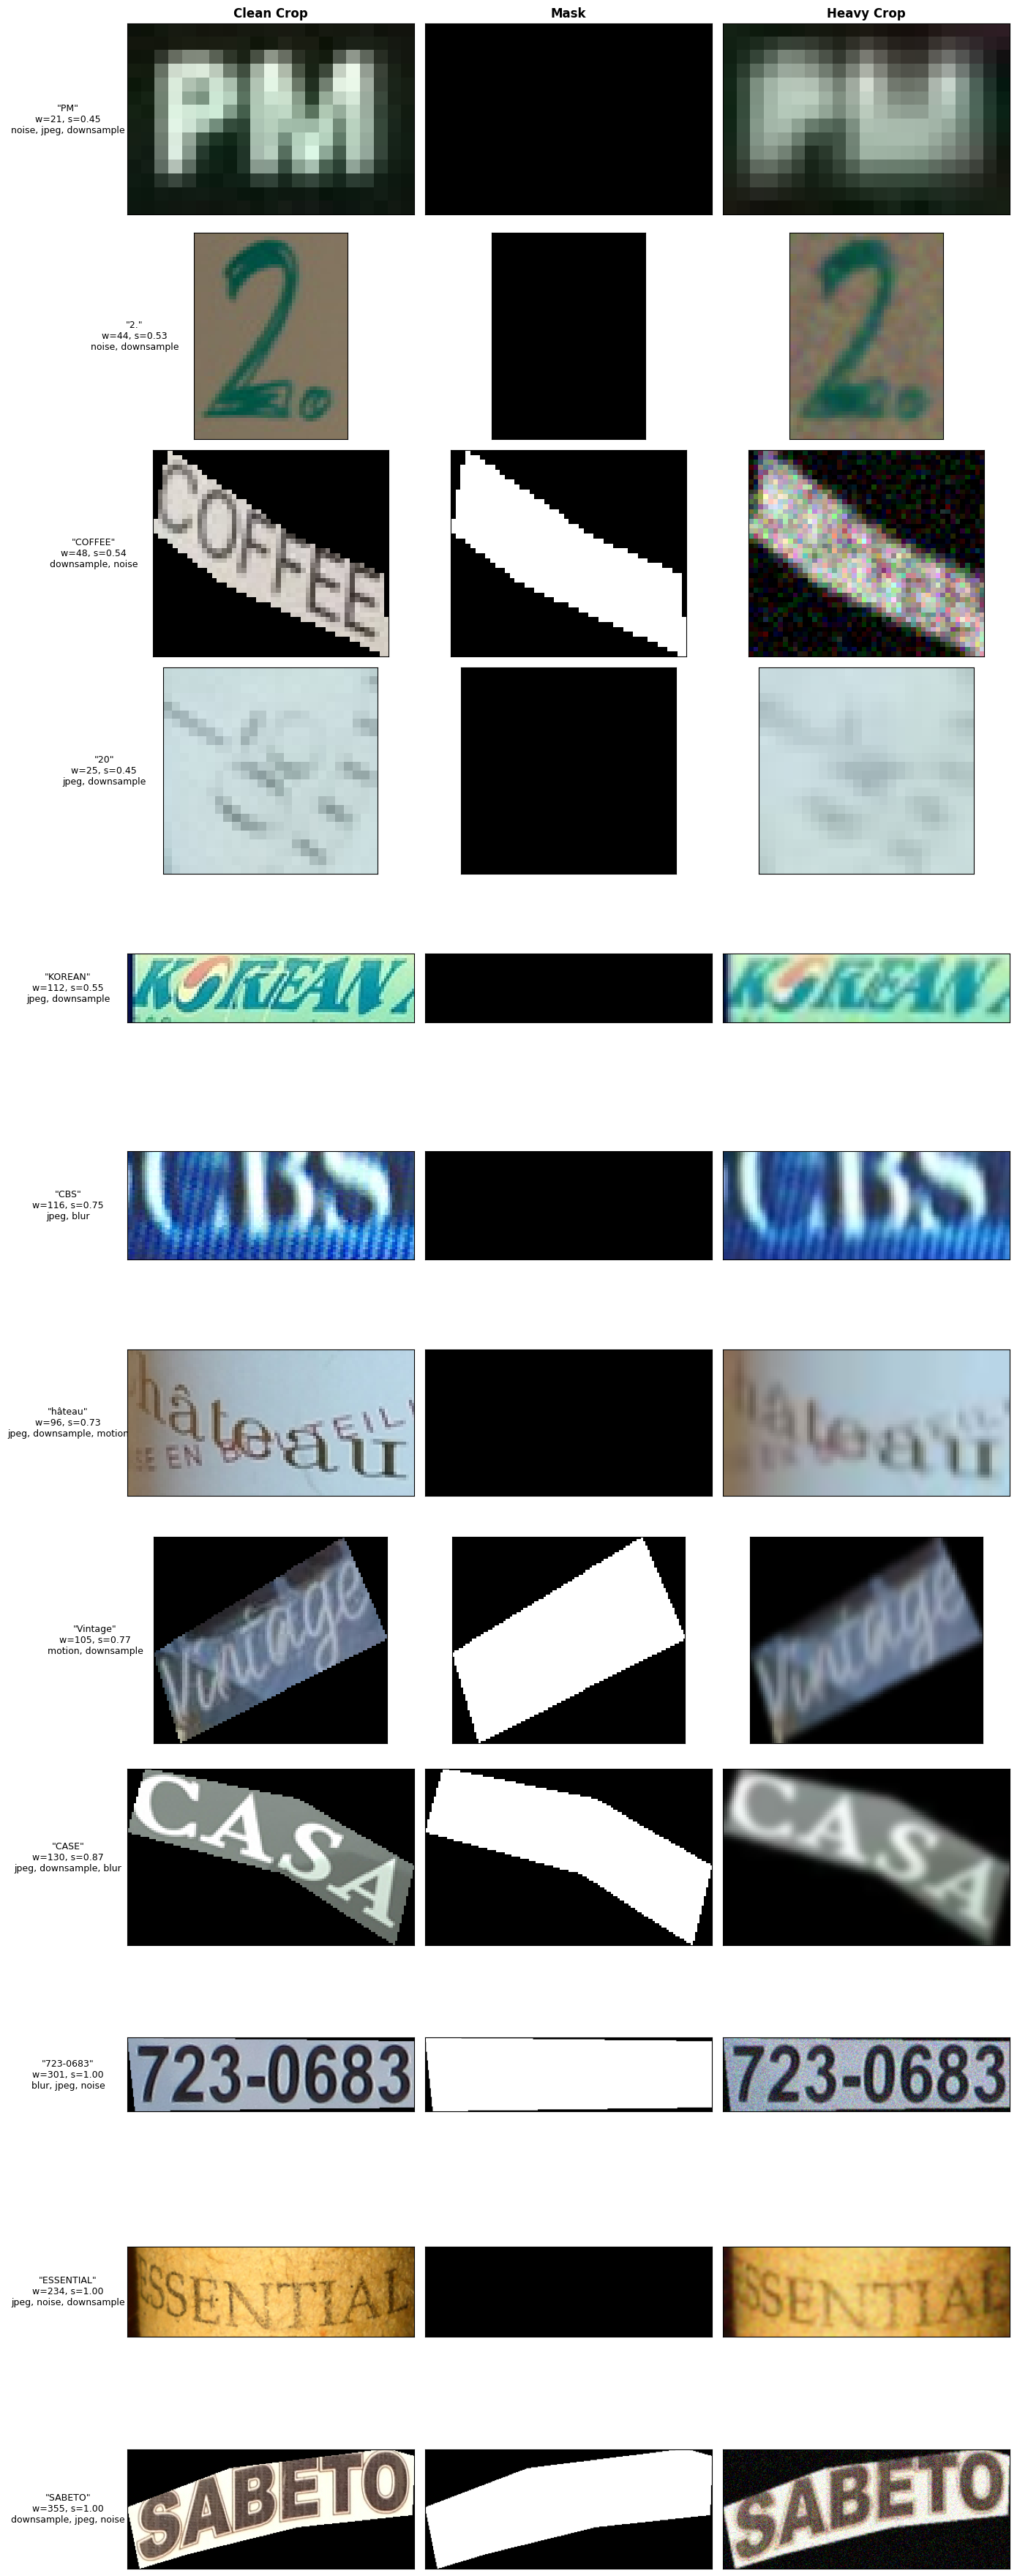

In [10]:
def summarize_benchmark_records(records):
    width_buckets = {'small': 0, 'medium': 0, 'large': 0}
    op_histogram = Counter()

    for record in records:
        clean_path = record.get('clean_crop_path', record['crop_path'])
        crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        if crop is None:
            continue
        width = crop.shape[1]
        if width < 64:
            width_buckets['small'] += 1
        elif width < 128:
            width_buckets['medium'] += 1
        else:
            width_buckets['large'] += 1
        for op in record.get('degradation_ops', []):
            op_histogram[op] += 1

    print(f'{cfg.BENCHMARK_NAME.title()} benchmark width buckets: {width_buckets}')
    print(f'{cfg.BENCHMARK_NAME.title()} benchmark op histogram: {dict(op_histogram)}')


def select_records_by_width(records, per_bucket=4, seed=42):
    rng = random.Random(seed)
    buckets = {'small': [], 'medium': [], 'large': []}

    for record in records:
        clean_path = record.get('clean_crop_path', record['crop_path'])
        crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        if crop is None:
            continue
        width = crop.shape[1]
        if width < 64:
            buckets['small'].append(record)
        elif width < 128:
            buckets['medium'].append(record)
        else:
            buckets['large'].append(record)

    selected = []
    for bucket_name in ['small', 'medium', 'large']:
        bucket = buckets[bucket_name]
        if len(bucket) <= per_bucket:
            selected.extend(bucket)
        else:
            selected.extend(rng.sample(bucket, per_bucket))
    return selected


def visualize_benchmark_crops(records, per_bucket=4, seed=42):
    selected = select_records_by_width(records, per_bucket=per_bucket, seed=seed)
    if not selected:
        raise ValueError('No records available for visualization.')

    _, axes = plt.subplots(len(selected), 3, figsize=(14, max(3 * len(selected), 8)))
    if len(selected) == 1:
        axes = np.expand_dims(axes, axis=0)

    axes[0, 0].set_title('Clean Crop', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Mask', fontsize=12, fontweight='bold')
    axes[0, 2].set_title(f'{cfg.BENCHMARK_NAME.title()} Crop', fontsize=12, fontweight='bold')

    for row, record in enumerate(selected):
        clean_path = record.get('clean_crop_path', record['crop_path'])
        clean_crop = cv2.imread(clean_path, cv2.IMREAD_COLOR)
        degraded_crop = cv2.imread(record['crop_path'], cv2.IMREAD_COLOR)
        mask = cv2.imread(record['mask_path'], cv2.IMREAD_GRAYSCALE) if record.get('mask_path') else None
        if clean_crop is None or degraded_crop is None:
            continue

        clean_rgb = cv2.cvtColor(clean_crop, cv2.COLOR_BGR2RGB)
        degraded_rgb = cv2.cvtColor(degraded_crop, cv2.COLOR_BGR2RGB)
        width = clean_crop.shape[1]
        ops = ', '.join(record.get('degradation_ops', [])) or 'none'
        scale = record.get('size_scale', 1.0)

        axes[row, 0].imshow(clean_rgb)
        axes[row, 1].imshow(mask if mask is not None else np.zeros(clean_crop.shape[:2], dtype=np.uint8), cmap='gray')
        axes[row, 2].imshow(degraded_rgb)

        axes[row, 0].set_ylabel(
            f'"{record["text"]}"\nw={width}, s={scale:.2f}\n{ops}',
            fontsize=9,
            rotation=0,
            labelpad=58,
            va='center',
        )
        for col in range(3):
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    plt.tight_layout()
    plt.show()


summarize_benchmark_records(final_test_records)
visualize_benchmark_crops(final_test_records, per_bucket=4, seed=cfg.SEED)

In [11]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---------------------------------------------------------------------------
# Model Architecture (matches Clovaai exactly)
# ---------------------------------------------------------------------------
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        recurrent, _ = self.rnn(x)
        return self.linear(recurrent)


class ClovaaiCRNN(nn.Module):
    """
    CRNN matching Clovaai's None-VGG-BiLSTM-CTC architecture.

    Key dimensions (for 32xW grayscale input):
      CNN: 1 -> 64 -> 128 -> 256 -> 256 -> 512(BN) -> 512(BN) -> 512(BN)
      Height: 32 -> 16 -> 8 -> 8 -> 4 -> 4 -> 2 -> 1
      Width:  W -> W/2 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4
      So W=256 -> 64 time steps for the RNN.

    Args:
        num_classes:    alphabet size including CTC blank (index 0)
        input_channel:  1 for grayscale
        output_channel: 512 (CNN final output channels)
        hidden_size:    256 (BiLSTM hidden per direction)
    """

    def __init__(self, num_classes, input_channel=1, output_channel=512,
                 hidden_size=256):
        super().__init__()
        self.num_classes = num_classes
        self.hidden_size = hidden_size
        self.output_channel = output_channel

        # -- VGG Feature Extractor (matches Clovaai exactly) --
        # Channel progression: [64, 128, 256, 512]
        oc = [output_channel // 8, output_channel // 4,
              output_channel // 2, output_channel]  # [64, 128, 256, 512]

        self.FeatureExtraction = nn.Sequential(
            nn.Conv2d(input_channel, oc[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 64x16xW/2

            nn.Conv2d(oc[0], oc[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 128x8xW/4

            nn.Conv2d(oc[1], oc[2], 3, 1, 1), nn.ReLU(True),            # -> 256x8xW/4
            nn.Conv2d(oc[2], oc[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 256x4xW/4

            nn.Conv2d(oc[2], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x4xW/4

            nn.Conv2d(oc[3], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 512x2xW/4

            nn.Conv2d(oc[3], oc[3], 2, 1, 0, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x1xW/4
        )

        # Collapse height
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        # -- BiLSTM Sequence Modeling --
        # Clovaai uses: BiLSTM(512->256->256) then BiLSTM(256->256->256)
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(output_channel, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )

        # -- CTC Prediction --
        # This layer gets replaced when loading pretrained weights
        self.Prediction = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 32, W) grayscale input
        Returns:
            log_probs: (T, B, num_classes) for CTC
        """
        # CNN: (B, 1, 32, W) -> (B, 512, 1, W/4)
        visual = self.FeatureExtraction(x)

        # Permute and pool: (B, 512, 1, W/4) -> (B, W/4, 512)
        visual = visual.permute(0, 3, 1, 2)      # (B, W/4, 512, 1)
        visual = self.AdaptiveAvgPool(visual)     # (B, W/4, 512, 1)
        visual = visual.squeeze(3)                # (B, W/4, 512)

        # BiLSTM: (B, T, 512) -> (B, T, 256)
        contextual = self.SequenceModeling(visual)

        # Prediction: (B, T, 256) -> (B, T, num_classes)
        output = self.Prediction(contextual)

        # CTC format: (T, B, num_classes)
        output = output.permute(1, 0, 2)
        log_probs = F.log_softmax(output, dim=2)
        return log_probs

In [12]:
# ---------------------------------------------------------------------------
# Weight Loading
# ---------------------------------------------------------------------------

CLOVAAI_DROPBOX_ARCHIVE_URL = (
    'https://www.dropbox.com/scl/fo/txf1v9m8p6xs8lq0yo0sc/'
    'AKjBi0yrQETefIvV_fXwXfQ?rlkey=j179442w75t7s907w6qpwhaeu&dl=1'
 )
CLOVAAI_DROPBOX_CACHE_DIR = 'clovaai_pretrained_models'


def _extract_state_dict(ckpt):
    if isinstance(ckpt, dict) and 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
        ckpt = ckpt['state_dict']
    if not isinstance(ckpt, dict):
        raise ValueError('Checkpoint does not contain a state_dict-like mapping.')
    tensor_items = {k: v for k, v in ckpt.items() if torch.is_tensor(v)}
    if not tensor_items:
        raise ValueError('Checkpoint does not contain tensor parameters.')
    return tensor_items


def _load_checkpoint_state(weights_path, device='cpu'):
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    stripped_state = {}
    for key, value in _extract_state_dict(ckpt).items():
        stripped_state[key.replace('module.', '')] = value
    return stripped_state


def _download_dropbox_archive(archive_url, archive_path):
    import shutil
    import urllib.request

    tmp_path = f'{archive_path}.part'
    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    request = urllib.request.Request(
        archive_url,
        headers={'User-Agent': 'Mozilla/5.0'},
    )

    print(f'Downloading pretrained archive from Dropbox to {archive_path}')
    with urllib.request.urlopen(request) as response, open(tmp_path, 'wb') as output_file:
        shutil.copyfileobj(response, output_file)

    os.replace(tmp_path, archive_path)


def _find_pretrained_checkpoint(root_dir, preferred_names=None, required_tokens=None):
    preferred_names = preferred_names or []
    required_tokens = [token.lower() for token in (required_tokens or [])]
    preferred_set = set(preferred_names)
    fallback_matches = []

    for dirpath, _, filenames in os.walk(root_dir):
        for filename in filenames:
            if not filename.endswith('.pth'):
                continue

            full_path = os.path.join(dirpath, filename)
            if filename in preferred_set:
                return full_path

            lower_name = filename.lower()
            if all(token in lower_name for token in required_tokens):
                fallback_matches.append(full_path)

    if fallback_matches:
        return sorted(fallback_matches)[0]
    return None


def _ensure_dropbox_pretrained_file(
    save_path,
    preferred_names,
    required_tokens,
    validator,
    archive_url=CLOVAAI_DROPBOX_ARCHIVE_URL,
    cache_dir=CLOVAAI_DROPBOX_CACHE_DIR,
 ):
    import shutil
    import zipfile

    if os.path.exists(save_path) and validator(save_path):
        print(f'Pretrained weights already exist at {save_path}')
        return save_path

    if os.path.exists(save_path):
        print(f'Existing file at {save_path} is invalid. Refreshing from Dropbox archive...')
        os.remove(save_path)

    os.makedirs(cache_dir, exist_ok=True)
    extracted_dir = os.path.join(cache_dir, 'dropbox_pretrained_model')

    cached_path = None
    if os.path.isdir(extracted_dir):
        cached_path = _find_pretrained_checkpoint(
            extracted_dir,
            preferred_names=preferred_names,
            required_tokens=required_tokens,
        )
        if cached_path and validator(cached_path):
            if os.path.abspath(cached_path) != os.path.abspath(save_path):
                shutil.copy2(cached_path, save_path)
            print(f'Using cached pretrained weights from {cached_path}')
            return save_path

    archive_path = os.path.join(cache_dir, 'pretrained_model.zip')
    if not os.path.exists(archive_path) or not zipfile.is_zipfile(archive_path):
        if os.path.exists(archive_path):
            os.remove(archive_path)
        _download_dropbox_archive(archive_url, archive_path)

    if os.path.isdir(extracted_dir):
        shutil.rmtree(extracted_dir)
    os.makedirs(extracted_dir, exist_ok=True)

    print(f'Extracting pretrained archive into {extracted_dir}')
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(extracted_dir)

    cached_path = _find_pretrained_checkpoint(
        extracted_dir,
        preferred_names=preferred_names,
        required_tokens=required_tokens,
    )
    if not cached_path:
        raise FileNotFoundError(
            f'Could not find a checkpoint matching {preferred_names or required_tokens} in the Dropbox archive.'
        )

    if not validator(cached_path):
        raise ValueError(
            f'Found checkpoint at {cached_path}, but it did not match the expected model format.'
        )

    if os.path.abspath(cached_path) != os.path.abspath(save_path):
        shutil.copy2(cached_path, save_path)

    print(f'Saved pretrained weights to {save_path}')
    return save_path


def _is_clova_vgg_ctc_checkpoint(weights_path, device='cpu', verbose=True):
    try:
        state = _load_checkpoint_state(weights_path, device=device)
    except Exception as exc:
        if verbose:
            print(f'Checkpoint validation failed for {weights_path}: {exc}')
        return False

    required_keys = {
        'FeatureExtraction.ConvNet.0.weight',
        'SequenceModeling.0.rnn.weight_ih_l0',
    }
    missing = [key for key in required_keys if key not in state]
    if missing:
        if verbose:
            sample_keys = list(state.keys())[:8]
            print('Checkpoint does not look like Clova None-VGG-BiLSTM-CTC.')
            print(f'Missing required keys: {missing}')
            print(f'Sample checkpoint keys: {sample_keys}')
        return False
    return True


def download_pretrained_weights(save_path='clovaai_crnn_pretrained.pth'):
    """Resolve the None-VGG-BiLSTM-CTC checkpoint from the shared Dropbox archive."""
    return _ensure_dropbox_pretrained_file(
        save_path=save_path,
        preferred_names=['None-VGG-BiLSTM-CTC.pth'],
        required_tokens=['none', 'vgg', 'bilstm', 'ctc'],
        validator=lambda path: _is_clova_vgg_ctc_checkpoint(path, device='cpu', verbose=False),
    )


def load_clovaai_pretrained(model, weights_path, device='cuda'):
    """
    Load Clovaai VGG-BiLSTM-CTC pretrained weights into our model.

    The feature extractor and both BiLSTM layers should load almost completely.
    The Prediction layer is only loaded when the output shape matches.
    """
    print(f'Loading pretrained weights from {weights_path}')
    pretrained_state = _load_checkpoint_state(weights_path, device=device)

    own_state = model.state_dict()
    loaded_feature = 0
    loaded_sequence = 0
    loaded_prediction = 0
    skipped = 0
    mismatch_examples = []

    for name, param in pretrained_state.items():
        remapped = name.replace('FeatureExtraction.ConvNet.', 'FeatureExtraction.')

        if remapped not in own_state:
            skipped += 1
            continue

        if own_state[remapped].shape != param.shape:
            skipped += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f'{remapped}: pretrained={tuple(param.shape)}, ours={tuple(own_state[remapped].shape)}'
                )
            continue

        own_state[remapped].copy_(param)
        if remapped.startswith('FeatureExtraction.'):
            loaded_feature += 1
        elif remapped.startswith('SequenceModeling.'):
            loaded_sequence += 1
        elif remapped.startswith('Prediction.'):
            loaded_prediction += 1

    model.load_state_dict(own_state)

    print(
        f'Loaded feature params: {loaded_feature}, '
        f'sequence params: {loaded_sequence}, '
        f'prediction params: {loaded_prediction}, skipped: {skipped}'
    )
    if mismatch_examples:
        print('Sample mismatches:')
        for example in mismatch_examples:
            print(f'  - {example}')

    if loaded_feature == 0 or loaded_sequence == 0:
        raise ValueError(
            'Checkpoint load failed: expected VGG feature weights and BiLSTM weights were not loaded. '
            'The downloaded file is likely not the Clova None-VGG-BiLSTM-CTC model.'
        )

    if loaded_prediction == 0:
        print('Prediction layer was not loaded, which is expected when num_classes differs.')

    return model

In [13]:
# ---------------------------------------------------------------------------
# Build and Initialize
# ---------------------------------------------------------------------------

def build_pretrained_crnn(label_encoder, cfg, device=None):
    """
    Complete setup: build model, download weights, load, move to device.

    Returns model ready for fine-tuning.
    """
    device = device or cfg.DEVICE

    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    # Download and load pretrained weights
    weights_path = download_pretrained_weights()
    model = load_clovaai_pretrained(model, weights_path, device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,}")

    return model


# ---------------------------------------------------------------------------
# Training with Differential LR
# ---------------------------------------------------------------------------

def train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder):
    """
    Fine-tuning loop with differential learning rates.

    CNN (pretrained):   LR * 0.1
    BiLSTM (pretrained): LR * 0.5
    Prediction (new):    LR * 1.0
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    # Three param groups with different LRs
    cnn_params = [p for n, p in model.named_parameters()
                  if 'FeatureExtraction' in n]
    rnn_params = [p for n, p in model.named_parameters()
                  if 'SequenceModeling' in n]
    pred_params = [p for n, p in model.named_parameters()
                   if 'Prediction' in n]

    optimizer = optim.Adam([
        {'params': cnn_params,  'lr': cfg.LR * 0.1},   # gentle on pretrained CNN
        {'params': rnn_params,  'lr': cfg.LR * 0.5},   # moderate on pretrained RNN
        {'params': pred_params, 'lr': cfg.LR},          # full LR on new head
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]  # prediction head LR
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [14]:
# ---------------------------------------------------------------------------
# Training Utilities
# ---------------------------------------------------------------------------

class CTCLabelConverter:
    """Bridges between the label encoder and CTC loss input format."""

    @staticmethod
    def prepare_targets(targets, lengths):
        """
        CTC loss expects concatenated targets and a length tensor.
        Our collate_fn already produces this format, so this is a passthrough
        with validation.
        """
        assert targets.dim() == 1, "targets must be 1-D (concatenated)"
        assert lengths.sum().item() == targets.size(0), "length mismatch"
        return targets, lengths


class AverageMeter:
    """Running average tracker for loss and metrics."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


def greedy_decode(log_probs, label_encoder):
    """
    CTC greedy (best-path) decoding.

    Args:
        log_probs: (T, B, C) log-probabilities from the model
        label_encoder: LabelEncoder instance for index-to-char mapping

    Returns:
        list of decoded strings, one per batch element
    """
    # Argmax over classes at each time step
    _, preds = log_probs.max(2)  # (T, B)
    preds = preds.permute(1, 0)  # (B, T)

    decoded = []
    for i in range(preds.size(0)):
        raw = preds[i].cpu().tolist()
        text = label_encoder.decode(raw, remove_duplicates=True, remove_blank=True)
        decoded.append(text)
    return decoded


def compute_metrics(predictions, ground_truths):
    """
    Compute word-level accuracy and character error rate (CER).

    Args:
        predictions:    list of predicted strings
        ground_truths:  list of ground truth strings

    Returns:
        dict with 'word_acc' (exact match %) and 'cer' (character error rate %)
    """
    assert len(predictions) == len(ground_truths)

    correct = 0
    total_edit_dist = 0
    total_gt_len = 0

    for pred, gt in zip(predictions, ground_truths):
        if pred == gt:
            correct += 1
        total_edit_dist += editdistance.eval(pred, gt)
        total_gt_len += max(len(gt), 1)  # avoid division by zero

    n = max(len(predictions), 1)
    word_acc = 100.0 * correct / n
    cer = 100.0 * total_edit_dist / max(total_gt_len, 1)

    return {"word_acc": word_acc, "cer": cer}

In [15]:
# ---------------------------------------------------------------------------
# Training & Evaluation Loops
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device, label_encoder,
                    grad_clip=5.0):
    """
    Single training epoch.

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, targets, lengths = batch
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        # Forward
        log_probs = model(images)  # (T, B, C)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        # CTC loss
        loss = criterion(log_probs, targets, input_lengths, lengths)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), B)

        # Decode for metrics (no grad needed, already detached via .data)
        with torch.no_grad():
            preds = greedy_decode(log_probs, label_encoder)

        # Reconstruct ground truth strings from concatenated targets
        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, label_encoder):
    """
    Evaluation pass (validation or test).

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, targets, lengths = batch
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        log_probs = model(images)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        loss = criterion(log_probs, targets, input_lengths, lengths)
        loss_meter.update(loss.item(), B)

        preds = greedy_decode(log_probs, label_encoder)

        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics

In [16]:
def train(model, train_loader, val_loader, cfg, label_encoder):
    """
    Full training loop with LR scheduling, gradient clipping, and
    best-model checkpointing based on validation word accuracy.

    Args:
        model:          CRNN instance (already on device)
        train_loader:   training DataLoader
        val_loader:     validation DataLoader
        cfg:            Config object
        label_encoder:  LabelEncoder instance

    Returns:
        history: dict of lists keyed by metric name
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [],
        "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        # -- Train --
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        # -- Validate --
        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        # -- LR step --
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        # -- Log --
        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        # -- Checkpoint best model --
        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
                "cfg": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [17]:
# ---------------------------------------------------------------------------
# Inference Helpers
# ---------------------------------------------------------------------------

def load_model(checkpoint_path, label_encoder, cfg, device=None):
    """
    Load a trained ClovaaiCRNN checkpoint for inference.

    Args:
        checkpoint_path:  path to .pth file saved by training
        label_encoder:    LabelEncoder matching the training charset
        cfg:              Config object
        device:           target device (defaults to cfg.DEVICE)

    Returns:
        model on the specified device, in eval mode
    """
    device = device or cfg.DEVICE
    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
          f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)")
    return model


def predict_batch(model, images, label_encoder, device=None):
    """
    Run inference on a batch of preprocessed image tensors.

    Args:
        model:          ClovaaiCRNN in eval mode
        images:         (B, 1, H, W) tensor
        label_encoder:  LabelEncoder instance
        device:         target device

    Returns:
        list of predicted strings
    """
    device = device or next(model.parameters()).device
    images = images.to(device)
    with torch.no_grad():
        log_probs = model(images)
    return greedy_decode(log_probs, label_encoder)

In [18]:
print(f"Train records: {len(final_train_records)}")
print(f"Train batches: {len(train_loader)}")

Train records: 89255
Train batches: 1372


In [19]:
# widths = []
# for img_path, text, polygon in final_train_records[:2000]:
#     img = cv2.imread(img_path)
#     if img is None:
#         continue
#     crop = crop_polygon_region(img, polygon, target_h=32)
#     if crop is not None:
#         widths.append(crop.shape[1])

# print(f"Width stats: min={min(widths)}, max={max(widths)}, "
#       f"mean={np.mean(widths):.0f}, median={np.median(widths):.0f}, "
#       f"95th={np.percentile(widths, 95):.0f}")

In [20]:
# ---------------------------------------------------------------------------
# Training with optional freezing for ClovaaiCRNN
# ---------------------------------------------------------------------------

def set_module_trainable(module, trainable):
    for param in module.parameters():
        param.requires_grad = trainable


def train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder):
    """
    Training loop with feature-extractor freeze/unfreeze schedule.

    Strategy:
      - Epochs 1 to freeze_cnn: feature extractor frozen, sequence/head train
      - Remaining epochs: full fine-tuning with lower LR for the feature extractor
    """
    device = cfg.DEVICE
    freeze_epochs = getattr(cfg, 'FREEZE_CNN_EPOCHS', 0)

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    feat_params = [p for n, p in model.named_parameters() if n.startswith('FeatureExtraction')]
    seq_params = [p for n, p in model.named_parameters() if n.startswith('SequenceModeling')]
    pred_params = [p for n, p in model.named_parameters() if n.startswith('Prediction')]

    optimizer = optim.Adam([
        {'params': feat_params, 'lr': cfg.LR * 0.1},
        {'params': seq_params, 'lr': cfg.LR * 0.5},
        {'params': pred_params, 'lr': cfg.LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    if freeze_epochs > 0:
        set_module_trainable(model.FeatureExtraction, False)

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        if freeze_epochs > 0 and epoch == freeze_epochs + 1:
            set_module_trainable(model.FeatureExtraction, True)
            print(f"       ** Unfreezing feature extractor at epoch {epoch}")

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [21]:
# if __name__ == "__main__":
#     # Add these to your Config:
#     # FREEZE_CNN_EPOCHS = 3    # freeze CNN for first 3 epochs
#     # LR = 1e-4               # keep the lower LR that was working

#     model = ResNetCRNN(
#         num_classes=label_encoder.num_classes,
#         rnn_hidden=cfg.RNN_HIDDEN_SIZE,
#         rnn_layers=cfg.RNN_NUM_LAYERS,
#         rnn_dropout=cfg.RNN_DROPOUT,
#         pretrained=True,
#         freeze_cnn=getattr(cfg, 'FREEZE_CNN_EPOCHS', 0),
#     ).to(cfg.DEVICE)

#     total = sum(p.numel() for p in model.parameters())
#     trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"Total parameters:     {total:,}")
#     print(f"Trainable parameters: {trainable:,}")
#     print(f"CNN params: {model.cnn_params:,}, RNN params: {model.rnn_params:,}")

#     history = train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder)
#     # plot_training_history(history)

#     # Final test
#     criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
#     test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
#     print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
#           f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

In [22]:
if __name__ == "__main__":
    # Optional CRNN fine-tuning overrides:
    # cfg.BATCH_SIZE = 48        # lower if GPU memory is tight
    # cfg.LR = 2e-4
    # cfg.NUM_EPOCHS = 18
    # cfg.LR_STEP = 6
    # cfg.LR_GAMMA = 0.7
    # cfg.FREEZE_CNN_EPOCHS = 1
    # cfg.WEIGHT_DECAY = 5e-5

    model = build_pretrained_crnn(label_encoder, cfg)

    history = train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder)
    # plot_training_history(history)

    # Final test
    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
    print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
          f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

Extracting pretrained archive into clovaai_pretrained_models/dropbox_pretrained_model
Saved pretrained weights to clovaai_crnn_pretrained.pth
Loading pretrained weights from clovaai_crnn_pretrained.pth
Loaded feature params: 21, sequence params: 20, prediction params: 2, skipped: 1
Total parameters:     8,452,133
Trainable parameters: 8,452,133
Epoch |  TrLoss |  TrAcc |  TrCER |  VaLoss |  VaAcc |  VaCER |        LR |  Time
----------------------------------------------------------------------
    1 |  2.4661 |  22.9% |  61.0% |  2.1956 |  28.6% |  56.5% | 2.00e-04 |   88s
       ** Saved best model (val_acc=28.6%)
    2 |  2.1404 |  28.3% |  55.2% |  2.0837 |  30.5% |  54.6% | 2.00e-04 |   87s
       ** Saved best model (val_acc=30.5%)
    3 |  2.0320 |  30.3% |  53.0% |  2.0165 |  31.8% |  53.6% | 2.00e-04 |   87s
       ** Saved best model (val_acc=31.8%)
    4 |  1.9588 |  31.6% |  51.5% |  1.9830 |  32.6% |  52.3% | 2.00e-04 |   87s
       ** Saved best model (val_acc=32.6%)
    

In [23]:
# ---------------------------------------------------------------------------
# TRBA dataset setup (TPS-ResNet-BiLSTM-Attn, Clovaai pretrained)
# ---------------------------------------------------------------------------

TRBA_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'


class AttnLabelConverter:
    """Character converter for attention-based decoding with [GO] and [s] tokens."""

    def __init__(self, character):
        self.character = ['[GO]', '[s]'] + list(character)
        self.dict = {char: idx for idx, char in enumerate(self.character)}
        self.go_idx = self.dict['[GO]']
        self.eos_idx = self.dict['[s]']

    def encode(self, texts, batch_max_length=25):
        lengths = [len(text) + 1 for text in texts]
        batch_text = torch.zeros(len(texts), batch_max_length + 2, dtype=torch.long)
        for row, text in enumerate(texts):
            tokens = list(text) + ['[s]']
            token_ids = [self.dict[token] for token in tokens]
            batch_text[row, 1:1 + len(token_ids)] = torch.tensor(token_ids, dtype=torch.long)
        return batch_text, torch.IntTensor(lengths)

    def decode(self, text_index, lengths=None):
        if isinstance(text_index, torch.Tensor):
            text_index = text_index.detach().cpu()
        texts = []
        for row in text_index:
            chars = []
            for token in row.tolist():
                char = self.character[int(token)]
                if char == '[GO]':
                    continue
                if char == '[s]':
                    break
                chars.append(char)
            texts.append(''.join(chars))
        return texts


class TRBAConfig(Config):
    IMG_WIDTH = 100
    IMG_CHANNELS = 1
    NUM_FIDUCIAL = 20
    BATCH_MAX_LENGTH = 25
    CHARACTER = TRBA_CHARSET
    BATCH_SIZE = 64
    NUM_EPOCHS = 5
    LR = 2e-4
    LR_STEP = 8
    LR_GAMMA = 0.7
    WEIGHT_DECAY = 1e-4
    SAVE_PATH = 'trba_totaltext_heavy_best.pth'


trba_cfg = TRBAConfig()
trba_label_encoder = LabelEncoder(trba_cfg.CHARACTER)
trba_converter = AttnLabelConverter(trba_cfg.CHARACTER)


TRBA_CHARSET_SET = set(TRBA_CHARSET)


def normalize_trba_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in TRBA_CHARSET_SET)
    return text


def build_trba_records(records, max_length):
    normalized_records = []
    skipped = 0

    for record in records:
        normalized = normalize_trba_text(record['text'])
        if not normalized or len(normalized) > max_length:
            skipped += 1
            continue

        updated = dict(record)
        updated['text'] = normalized
        normalized_records.append(updated)

    print(f'Kept {len(normalized_records)} / {len(records)} records for TRBA (skipped {skipped})')
    return normalized_records


class TRBADataset(Dataset):
    """Keep-ratio resize with right padding to match Clova TRBA preprocessing."""

    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records = records
        self.label_encoder = label_encoder
        self.cfg = cfg
        self.augment = augment
        self.max_width = cfg.IMG_WIDTH
        self.height = cfg.IMG_HEIGHT
        self.pil_transform = build_recognition_pil_augmentation(cfg) if augment else None

        channel_mean = [0.5] * cfg.IMG_CHANNELS
        channel_std = [0.5] * cfg.IMG_CHANNELS
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=channel_mean, std=channel_std),
        ])

    def __len__(self):
        return len(self.records)

    def _resize_keep_ratio_pad(self, crop):
        if crop.ndim == 2:
            h, w = crop.shape
        else:
            h, w = crop.shape[:2]

        if h != self.height:
            new_w = max(1, int(round(w * (self.height / max(h, 1)))))
            crop = cv2.resize(crop, (new_w, self.height), interpolation=cv2.INTER_CUBIC)
            h, w = crop.shape[:2]

        target_w = min(self.max_width, max(1, int(np.ceil(self.height * (w / max(h, 1))))))
        if w != target_w:
            crop = cv2.resize(crop, (target_w, self.height), interpolation=cv2.INTER_CUBIC)

        if target_w < self.max_width:
            pad_w = self.max_width - target_w
            border_value = 0 if crop.ndim == 2 else [0] * crop.shape[2]
            crop = cv2.copyMakeBorder(crop, 0, 0, 0, pad_w, cv2.BORDER_REPLICATE, value=border_value)

        return crop[:, :self.max_width]

    def __getitem__(self, idx):
        record = self.records[idx]
        img_path = record['crop_path']
        text = record['text']

        crop = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if crop is None:
            return None

        if self.cfg.IMG_CHANNELS == 1:
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        else:
            crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        crop = self._resize_keep_ratio_pad(crop)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)


class AttentionCollate:
    """Reuse dataset outputs and repack targets for attention training."""

    def __init__(self, label_encoder, converter, batch_max_length):
        self.label_encoder = label_encoder
        self.converter = converter
        self.batch_max_length = batch_max_length

    def __call__(self, batch):
        batch = [sample for sample in batch if sample is not None]
        if not batch:
            return None

        images, labels, _ = zip(*batch)
        images = torch.stack(images, 0)
        texts = [
            self.label_encoder.decode(label.tolist(), remove_duplicates=False, remove_blank=True)
            for label in labels
        ]
        encoded_texts, lengths = self.converter.encode(texts, batch_max_length=self.batch_max_length)
        return images, encoded_texts, lengths, texts


trba_train_records = build_trba_records(final_train_records, trba_cfg.BATCH_MAX_LENGTH)
trba_val_records = build_trba_records(final_val_records, trba_cfg.BATCH_MAX_LENGTH)
trba_test_records = build_trba_records(final_test_records, trba_cfg.BATCH_MAX_LENGTH)

trba_train_ds = TRBADataset(trba_train_records, trba_label_encoder, trba_cfg, augment=True)
trba_val_ds = TRBADataset(trba_val_records, trba_label_encoder, trba_cfg, augment=False)
trba_test_ds = TRBADataset(trba_test_records, trba_label_encoder, trba_cfg, augment=False)

trba_collate = AttentionCollate(trba_label_encoder, trba_converter, trba_cfg.BATCH_MAX_LENGTH)

trba_train_loader = DataLoader(
    trba_train_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)
trba_val_loader = DataLoader(
    trba_val_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)
trba_test_loader = DataLoader(
    trba_test_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)

print(f'TRBA train batches: {len(trba_train_loader)}')
print(f'TRBA val batches:   {len(trba_val_loader)}')
print(f'TRBA test batches:  {len(trba_test_loader)}')

Kept 87804 / 89255 records for TRBA (skipped 1451)
Kept 10621 / 10798 records for TRBA (skipped 177)
Kept 10030 / 10364 records for TRBA (skipped 334)
TRBA train batches: 1372
TRBA val batches:   166
TRBA test batches:  157


In [24]:
# ---------------------------------------------------------------------------
# TRBA model architecture (matches Clovaai TPS-ResNet-BiLSTM-Attn)
# ---------------------------------------------------------------------------

import numpy as np


class TPS_SpatialTransformerNetwork(nn.Module):
    def __init__(self, F, I_size, I_r_size, I_channel_num=1):
        super().__init__()
        self.F = F
        self.I_size = I_size
        self.I_r_size = I_r_size
        self.I_channel_num = I_channel_num
        self.LocalizationNetwork = LocalizationNetwork(F, I_channel_num)
        self.GridGenerator = GridGenerator(F, I_r_size)

    def forward(self, batch_I):
        batch_C_prime = self.LocalizationNetwork(batch_I)
        build_P_prime = self.GridGenerator.build_P_prime(batch_C_prime)
        build_P_prime = build_P_prime.reshape(batch_I.size(0), self.I_r_size[0], self.I_r_size[1], 2)
        return F.grid_sample(batch_I, build_P_prime, padding_mode='border', align_corners=True)


class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super().__init__()
        self.F = F
        self.I_channel_num = I_channel_num
        self.conv = nn.Sequential(
            nn.Conv2d(I_channel_num, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.localization_fc1 = nn.Sequential(nn.Linear(512, 256), nn.ReLU(True))
        self.localization_fc2 = nn.Linear(256, F * 2)

        self.localization_fc2.weight.data.zero_()
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = np.linspace(0.0, -1.0, num=int(F / 2))
        ctrl_pts_y_bottom = np.linspace(1.0, 0.0, num=int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        initial_bias = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
        self.localization_fc2.bias.data.copy_(torch.from_numpy(initial_bias).float().view(-1))

    def forward(self, batch_I):
        batch_size = batch_I.size(0)
        features = self.conv(batch_I).view(batch_size, -1)
        return self.localization_fc2(self.localization_fc1(features)).view(batch_size, self.F, 2)


class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super().__init__()
        self.eps = 1e-6
        self.I_r_height, self.I_r_width = I_r_size
        self.F = F
        self.C = self._build_C(F)
        self.P = self._build_P(self.I_r_width, self.I_r_height)
        self.register_buffer('inv_delta_C', torch.tensor(self._build_inv_delta_C(F, self.C)).float())
        self.register_buffer('P_hat', torch.tensor(self._build_P_hat(F, self.C, self.P)).float())

    def _build_C(self, F):
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = -1 * np.ones(int(F / 2))
        ctrl_pts_y_bottom = np.ones(int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        return np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)

    def _build_inv_delta_C(self, F, C):
        hat_C = np.zeros((F, F), dtype=float)
        for i in range(F):
            for j in range(i, F):
                r = np.linalg.norm(C[i] - C[j])
                hat_C[i, j] = r
                hat_C[j, i] = r
        np.fill_diagonal(hat_C, 1)
        hat_C = (hat_C ** 2) * np.log(hat_C)
        delta_C = np.concatenate(
            [
                np.concatenate([np.ones((F, 1)), C, hat_C], axis=1),
                np.concatenate([np.zeros((2, 3)), C.T], axis=1),
                np.concatenate([np.zeros((1, 3)), np.ones((1, F))], axis=1),
            ],
            axis=0,
        )
        return np.linalg.inv(delta_C)

    def _build_P(self, I_r_width, I_r_height):
        I_r_grid_x = (np.arange(-I_r_width, I_r_width, 2) + 1.0) / I_r_width
        I_r_grid_y = (np.arange(-I_r_height, I_r_height, 2) + 1.0) / I_r_height
        P = np.stack(np.meshgrid(I_r_grid_x, I_r_grid_y), axis=2)
        return P.reshape([-1, 2])

    def _build_P_hat(self, F, C, P):
        n = P.shape[0]
        P_tile = np.tile(np.expand_dims(P, axis=1), (1, F, 1))
        C_tile = np.expand_dims(C, axis=0)
        P_diff = P_tile - C_tile
        rbf_norm = np.linalg.norm(P_diff, ord=2, axis=2)
        rbf = np.multiply(np.square(rbf_norm), np.log(rbf_norm + self.eps))
        return np.concatenate([np.ones((n, 1)), P, rbf], axis=1)

    def build_P_prime(self, batch_C_prime):
        batch_size = batch_C_prime.size(0)
        batch_inv_delta_C = self.inv_delta_C.unsqueeze(0).repeat(batch_size, 1, 1)
        batch_P_hat = self.P_hat.unsqueeze(0).repeat(batch_size, 1, 1)
        zeros = torch.zeros(batch_size, 3, 2, device=batch_C_prime.device, dtype=batch_C_prime.dtype)
        batch_C_prime_with_zeros = torch.cat((batch_C_prime, zeros), dim=1)
        batch_T = torch.bmm(batch_inv_delta_C, batch_C_prime_with_zeros)
        return torch.bmm(batch_P_hat, batch_T)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = self._conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = self._conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def _conv3x3(self, in_planes, out_planes, stride=1):
        return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, input_channel, output_channel, block, layers):
        super().__init__()
        self.output_channel_block = [int(output_channel / 4), int(output_channel / 2), output_channel, output_channel]
        self.inplanes = int(output_channel / 8)

        self.conv0_1 = nn.Conv2d(input_channel, int(output_channel / 16), kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_1 = nn.BatchNorm2d(int(output_channel / 16))
        self.conv0_2 = nn.Conv2d(int(output_channel / 16), self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_2 = nn.BatchNorm2d(self.inplanes)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer1 = self._make_layer(block, self.output_channel_block[0], layers[0])
        self.conv1 = nn.Conv2d(self.output_channel_block[0], self.output_channel_block[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.output_channel_block[0])

        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer2 = self._make_layer(block, self.output_channel_block[1], layers[1], stride=1)
        self.conv2 = nn.Conv2d(self.output_channel_block[1], self.output_channel_block[1], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.output_channel_block[1])

        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=(2, 1), padding=(0, 1))
        self.layer3 = self._make_layer(block, self.output_channel_block[2], layers[2], stride=1)
        self.conv3 = nn.Conv2d(self.output_channel_block[2], self.output_channel_block[2], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.output_channel_block[2])

        self.layer4 = self._make_layer(block, self.output_channel_block[3], layers[3], stride=1)
        self.conv4_1 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=(2, 1), padding=(0, 1), bias=False)
        self.bn4_1 = nn.BatchNorm2d(self.output_channel_block[3])
        self.conv4_2 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=1, padding=0, bias=False)
        self.bn4_2 = nn.BatchNorm2d(self.output_channel_block[3])

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv0_1(x)
        x = self.bn0_1(x)
        x = self.relu(x)
        x = self.conv0_2(x)
        x = self.bn0_2(x)
        x = self.relu(x)

        x = self.maxpool1(x)
        x = self.layer1(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool2(x)
        x = self.layer2(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.maxpool3(x)
        x = self.layer3(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.layer4(x)
        x = self.conv4_1(x)
        x = self.bn4_1(x)
        x = self.relu(x)
        x = self.conv4_2(x)
        x = self.bn4_2(x)
        x = self.relu(x)
        return x


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=512):
        super().__init__()
        self.ConvNet = ResNet(input_channel, output_channel, BasicBlock, [1, 2, 5, 3])

    def forward(self, x):
        return self.ConvNet(x)


class AttentionCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_embeddings):
        super().__init__()
        self.i2h = nn.Linear(input_size, hidden_size, bias=False)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)
        self.rnn = nn.LSTMCell(input_size + num_embeddings, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, prev_hidden, batch_H, char_onehots):
        batch_H_proj = self.i2h(batch_H)
        prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)
        e = self.score(torch.tanh(batch_H_proj + prev_hidden_proj))
        alpha = F.softmax(e, dim=1)
        context = torch.bmm(alpha.permute(0, 2, 1), batch_H).squeeze(1)
        concat_context = torch.cat([context, char_onehots], dim=1)
        cur_hidden = self.rnn(concat_context, prev_hidden)
        return cur_hidden, alpha


class Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.attention_cell = AttentionCell(input_size, hidden_size, num_classes)
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.generator = nn.Linear(hidden_size, num_classes)

    def _char_to_onehot(self, input_char, onehot_dim):
        input_char = input_char.unsqueeze(1)
        one_hot = torch.zeros(input_char.size(0), onehot_dim, device=input_char.device)
        return one_hot.scatter_(1, input_char, 1.0)

    def forward(self, batch_H, text, is_train=True, batch_max_length=25):
        batch_size = batch_H.size(0)
        num_steps = batch_max_length + 1
        output_hiddens = torch.zeros(batch_size, num_steps, self.hidden_size, device=batch_H.device)
        hidden = (
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
        )

        if is_train:
            for step in range(num_steps):
                char_onehots = self._char_to_onehot(text[:, step], onehot_dim=self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
                output_hiddens[:, step, :] = hidden[0]
            return self.generator(output_hiddens)

        targets = torch.zeros(batch_size, dtype=torch.long, device=batch_H.device)
        probs = torch.zeros(batch_size, num_steps, self.num_classes, device=batch_H.device)
        for step in range(num_steps):
            char_onehots = self._char_to_onehot(targets, onehot_dim=self.num_classes)
            hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
            probs_step = self.generator(hidden[0])
            probs[:, step, :] = probs_step
            _, next_input = probs_step.max(dim=1)
            targets = next_input
        return probs


class ClovaaiTRBA(nn.Module):
    def __init__(self, num_class, cfg):
        super().__init__()
        self.cfg = cfg
        self.stages = {'Trans': 'TPS', 'Feat': 'ResNet', 'Seq': 'BiLSTM', 'Pred': 'Attn'}
        self.Transformation = TPS_SpatialTransformerNetwork(
            F=cfg.NUM_FIDUCIAL,
            I_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_r_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_channel_num=cfg.IMG_CHANNELS,
        )
        self.FeatureExtraction = ResNetFeatureExtractor(cfg.IMG_CHANNELS, cfg.CNN_OUT_CHANNELS)
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(cfg.CNN_OUT_CHANNELS, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
            BidirectionalLSTM(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
        )
        self.Prediction = Attention(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, num_class)

    def forward(self, images, text, is_train=True):
        images = self.Transformation(images)
        visual_feature = self.FeatureExtraction(images)
        visual_feature = self.AdaptiveAvgPool(visual_feature.permute(0, 3, 1, 2))
        visual_feature = visual_feature.squeeze(3)
        contextual_feature = self.SequenceModeling(visual_feature)
        return self.Prediction(
            contextual_feature.contiguous(),
            text,
            is_train=is_train,
            batch_max_length=self.cfg.BATCH_MAX_LENGTH,
        )

In [25]:
# ---------------------------------------------------------------------------
# TRBA weight loading, training, evaluation, and inference
# ---------------------------------------------------------------------------


def _is_clova_trba_checkpoint(weights_path, device='cpu', verbose=True):
    try:
        state = _load_checkpoint_state(weights_path, device=device)
    except Exception as exc:
        if verbose:
            print(f'Checkpoint validation failed for {weights_path}: {exc}')
        return False

    required_keys = {
        'Transformation.LocalizationNetwork.conv.0.weight',
        'FeatureExtraction.ConvNet.conv0_1.weight',
        'SequenceModeling.0.rnn.weight_ih_l0',
        'Prediction.attention_cell.i2h.weight',
        'Prediction.generator.weight',
    }
    missing = [key for key in required_keys if key not in state]
    if missing:
        if verbose:
            sample_keys = list(state.keys())[:12]
            print('Checkpoint does not look like Clova TPS-ResNet-BiLSTM-Attn.')
            print(f'Missing required keys: {missing}')
            print(f'Sample checkpoint keys: {sample_keys}')
        return False
    return True


def download_trba_pretrained_weights(save_path='clovaai_trba_pretrained.pth'):
    """Resolve the TPS-ResNet-BiLSTM-Attn checkpoint from the shared Dropbox archive."""
    return _ensure_dropbox_pretrained_file(
        save_path=save_path,
        preferred_names=['TPS-ResNet-BiLSTM-Attn.pth'],
        required_tokens=['tps', 'resnet', 'bilstm', 'attn'],
        validator=lambda path: _is_clova_trba_checkpoint(path, device='cpu', verbose=False),
    )



def load_trba_pretrained(model, weights_path, device='cuda'):
    print(f'Loading pretrained weights from {weights_path}')
    pretrained_state = _load_checkpoint_state(weights_path, device=device)
    own_state = model.state_dict()

    loaded_transformation = 0
    loaded_feature = 0
    loaded_sequence = 0
    loaded_prediction = 0
    skipped = 0
    mismatch_examples = []

    for name, param in pretrained_state.items():
        if name not in own_state:
            skipped += 1
            continue

        if own_state[name].shape != param.shape:
            skipped += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f'{name}: pretrained={tuple(param.shape)}, ours={tuple(own_state[name].shape)}'
                )
            continue

        own_state[name].copy_(param)
        if name.startswith('Transformation.'):
            loaded_transformation += 1
        elif name.startswith('FeatureExtraction.'):
            loaded_feature += 1
        elif name.startswith('SequenceModeling.'):
            loaded_sequence += 1
        elif name.startswith('Prediction.'):
            loaded_prediction += 1

    model.load_state_dict(own_state)

    print(
        f'Loaded transformation params: {loaded_transformation}, '
        f'feature params: {loaded_feature}, '
        f'sequence params: {loaded_sequence}, '
        f'prediction params: {loaded_prediction}, skipped: {skipped}'
    )
    if mismatch_examples:
        print('Sample mismatches:')
        for example in mismatch_examples:
            print(f'  - {example}')

    if (
        loaded_transformation == 0
        or loaded_feature == 0
        or loaded_sequence == 0
        or loaded_prediction == 0
    ):
        raise ValueError(
            'Checkpoint load failed: expected TPS, ResNet, BiLSTM, and Attention weights were not all loaded. '
            'The downloaded file is likely not the Clova TPS-ResNet-BiLSTM-Attn checkpoint.'
        )

    return model



def attn_greedy_decode(logits, converter):
    _, preds_index = logits.max(2)
    return converter.decode(preds_index)



def build_pretrained_trba(converter, cfg, device=None):
    device = device or cfg.DEVICE
    model = ClovaaiTRBA(num_class=len(converter.character), cfg=cfg).to(device)
    weights_path = download_trba_pretrained_weights()
    model = load_trba_pretrained(model, weights_path, device=device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters:     {total:,}')
    print(f'Trainable parameters: {trainable:,}')
    return model



def train_one_epoch_attn(model, loader, criterion, optimizer, device, converter, cfg, grad_clip=5.0):
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, encoded_texts, _, texts = batch
        images = images.to(device)
        encoded_texts = encoded_texts.to(device)

        preds = model(images, encoded_texts[:, :-1], is_train=True)
        target = encoded_texts[:, 1:]
        loss = criterion(preds.contiguous().view(-1, preds.size(-1)), target.contiguous().view(-1))

        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), images.size(0))

        with torch.no_grad():
            text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
            pred_texts = attn_greedy_decode(model(images, text_for_pred, is_train=False), converter)

        all_preds.extend(pred_texts)
        all_gts.extend(texts)

    metrics = compute_metrics(all_preds, all_gts)
    metrics['loss'] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate_attn(model, loader, criterion, device, converter, cfg):
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for batch in loader:
        if batch is None:
            continue

        images, encoded_texts, _, texts = batch
        images = images.to(device)
        encoded_texts = encoded_texts.to(device)

        preds = model(images, encoded_texts[:, :-1], is_train=True)
        target = encoded_texts[:, 1:]
        loss = criterion(preds.contiguous().view(-1, preds.size(-1)), target.contiguous().view(-1))
        loss_meter.update(loss.item(), images.size(0))

        text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
        pred_texts = attn_greedy_decode(model(images, text_for_pred, is_train=False), converter)

        all_preds.extend(pred_texts)
        all_gts.extend(texts)

    metrics = compute_metrics(all_preds, all_gts)
    metrics['loss'] = loss_meter.avg
    return metrics



def train_pretrained_trba(model, train_loader, val_loader, cfg, converter):
    device = cfg.DEVICE
    criterion = nn.CrossEntropyLoss(ignore_index=converter.go_idx)

    tps_params = [p for n, p in model.named_parameters() if n.startswith('Transformation')]
    feat_params = [p for n, p in model.named_parameters() if n.startswith('FeatureExtraction')]
    seq_params = [p for n, p in model.named_parameters() if n.startswith('SequenceModeling')]
    pred_params = [p for n, p in model.named_parameters() if n.startswith('Prediction')]

    optimizer = optim.Adam(
        [
            {'params': tps_params, 'lr': cfg.LR * 0.05},
            {'params': feat_params, 'lr': cfg.LR * 0.10},
            {'params': seq_params, 'lr': cfg.LR * 0.25},
            {'params': pred_params, 'lr': cfg.LR * 0.50},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP, gamma=cfg.LR_GAMMA)

    history = {
        'train_loss': [], 'train_acc': [], 'train_cer': [],
        'val_loss': [], 'val_acc': [], 'val_cer': [], 'lr': [],
    }
    best_val_acc = 0.0

    print('=' * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print('-' * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()
        train_metrics = train_one_epoch_attn(
            model, train_loader, criterion, optimizer, device, converter, cfg, grad_clip=cfg.GRAD_CLIP
        )
        val_metrics = evaluate_attn(model, val_loader, criterion, device, converter, cfg)

        current_lr = optimizer.param_groups[-1]['lr']
        scheduler.step()

        elapsed = time.time() - t0
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['word_acc'])
        history['train_cer'].append(train_metrics['cer'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['word_acc'])
        history['val_cer'].append(val_metrics['cer'])
        history['lr'].append(current_lr)

        print(
            f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
            f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
            f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
            f"{current_lr:.2e} | {elapsed:4.0f}s"
        )

        if val_metrics['word_acc'] > best_val_acc:
            best_val_acc = val_metrics['word_acc']
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': best_val_acc,
                    'val_cer': val_metrics['cer'],
                    'character': cfg.CHARACTER,
                },
                cfg.SAVE_PATH,
            )
            print(f'       ** Saved best model (val_acc={best_val_acc:.1f}%)')

    print('=' * 70)
    print(f'Training complete. Best val accuracy: {best_val_acc:.1f}%')
    return history



def load_trba_model(checkpoint_path, converter, cfg, device=None):
    device = device or cfg.DEVICE
    model = ClovaaiTRBA(num_class=len(converter.character), cfg=cfg).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(
        f"Loaded checkpoint from epoch {ckpt['epoch']} "
        f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)"
    )
    return model



def predict_batch_attn(model, images, converter, cfg, device=None):
    device = device or next(model.parameters()).device
    images = images.to(device)
    text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
    with torch.no_grad():
        preds = model(images, text_for_pred, is_train=False)
    return attn_greedy_decode(preds, converter)

In [26]:
if __name__ == '__main__':
    # Optional TRBA fine-tuning overrides:
    # trba_cfg.BATCH_SIZE = 16   # lower if GPU memory is tight
    # trba_cfg.LR = 2e-4
    # trba_cfg.NUM_EPOCHS = 20
    # trba_cfg.LR_STEP = 8
    # trba_cfg.LR_GAMMA = 0.7
    # trba_cfg.WEIGHT_DECAY = 1e-4

    trba_model = build_pretrained_trba(trba_converter, trba_cfg)

    trba_history = train_pretrained_trba(
        trba_model,
        trba_train_loader,
        trba_val_loader,
        trba_cfg,
        trba_converter,
    )
    # plot_training_history(trba_history)

    trba_criterion = nn.CrossEntropyLoss(ignore_index=trba_converter.go_idx)
    trba_test_metrics = evaluate_attn(
        trba_model,
        trba_test_loader,
        trba_criterion,
        trba_cfg.DEVICE,
        trba_converter,
        trba_cfg,
    )
    print(
        f"\nTRBA Test -> Word Acc: {trba_test_metrics['word_acc']:.1f}%, "
        f"CER: {trba_test_metrics['cer']:.1f}%, Loss: {trba_test_metrics['loss']:.4f}"
    )

Using cached pretrained weights from clovaai_pretrained_models/dropbox_pretrained_model/TPS-ResNet-BiLSTM-Attn.pth
Loading pretrained weights from clovaai_trba_pretrained.pth
Loaded transformation params: 30, feature params: 192, sequence params: 20, prediction params: 10, skipped: 0
Total parameters:     49,555,182
Trainable parameters: 49,555,182
Epoch |  TrLoss |  TrAcc |  TrCER |  VaLoss |  VaAcc |  VaCER |        LR |  Time
----------------------------------------------------------------------
    1 |  1.3035 |  34.0% |  53.4% |  1.2103 |  38.0% |  50.6% | 1.00e-04 |  259s
       ** Saved best model (val_acc=38.0%)
    2 |  1.1224 |  39.7% |  47.5% |  1.1558 |  39.8% |  48.5% | 1.00e-04 |  259s
       ** Saved best model (val_acc=39.8%)
    3 |  1.0393 |  42.6% |  44.7% |  1.1305 |  40.6% |  47.7% | 1.00e-04 |  260s
       ** Saved best model (val_acc=40.6%)
    4 |  0.9772 |  45.0% |  42.5% |  1.1181 |  40.7% |  47.3% | 1.00e-04 |  260s
       ** Saved best model (val_acc=40.7%)


In [27]:
# ---------------------------------------------------------------------------
# SVTRv2 setup (OpenOCR, benchmark-aligned 94-char config, Union14M-L-Filter pretrained)
# ---------------------------------------------------------------------------
import importlib.util
import json
import os
import random
import re
import subprocess
import sys
import time
import unicodedata
from copy import deepcopy
from datetime import datetime, timedelta
from pathlib import Path

import yaml

SVTRV2_VARIANT = 'B'
SVTRV2_REPO_DIR = Path('third_party/OpenOCR')
SVTRV2_WORK_DIR = Path('artifacts/svtrv2_heavy')
SVTRV2_ASSET_DIR = SVTRV2_WORK_DIR / 'pretrained'
SVTRV2_LABEL_DIR = SVTRV2_WORK_DIR / 'labels'
SVTRV2_OUTPUT_DIR = SVTRV2_WORK_DIR / 'output'
SVTRV2_CHAR_DICT_PATH = SVTRV2_WORK_DIR / 'charset_94.txt'
SVTRV2_REQUIREMENTS_STAMP = SVTRV2_WORK_DIR / '.openocr_requirements_installed'
SVTRV2_BENCHMARK_CHARSET = ''.join(chr(code) for code in range(33, 127))
SVTRV2_MAX_TEXT_LENGTH = 25
SVTRV2_IMAGE_SHAPE = [3, 32, 128]
SVTRV2_GDRIVE_FOLDERS = {
    'T': '12ZUGkCS7tEhFhWa2RKKtyB0tPjhH4d9s',
    'S': '1mOG3EUAOsmD16B-VIelVDYf_O64q0G3M',
    'B': '11u11ptDzQ4BF9RRsOYdZnXl6ell2h4jN',
}
SVTRV2_DEFAULT_BASE_CONFIG = 'configs/rec/svtrv2/svtrv2_smtr_gtc_rctc.yml'
SVTRV2_DEFAULT_INFER_CONFIG = 'configs/rec/svtrv2/svtrv2_smtr_gtc_rctc_infer.yml'
SVTRV2_REQUIRED_CKPT_TOKENS = ('svtrv2', 'smtr', 'gtc', 'rctc')
SVTRV2_EXCLUDED_CKPT_TOKENS = ('student', 'onnx', 'infer')
SVTRV2_EPOCH_LOG_RE = re.compile(r'epoch:\s*\[(\d+)/(\d+)\]')
SVTRV2_TRAIN_SUMMARY_MARKERS = ('cur metric,', 'best metric,')


def svtrv2_run(cmd, cwd=None, capture_output=False):
    printable = ' '.join(str(part) for part in cmd)
    print(f'$ {printable}')
    return subprocess.run(
        [str(part) for part in cmd],
        cwd=str(cwd) if cwd else None,
        check=True,
        text=True,
        capture_output=capture_output,
    )


def ensure_python_package(import_name, pip_spec):
    if importlib.util.find_spec(import_name) is not None:
        return
    svtrv2_run([sys.executable, '-m', 'pip', 'install', '-q', pip_spec])


def load_yaml_config(config_path):
    with open(config_path, 'r', encoding='utf-8') as handle:
        return yaml.safe_load(handle)


def svtrv2_timestamp():
    return datetime.now().strftime('%Y-%m-%d %H:%M:%S')


def format_svtrv2_duration(seconds):
    return str(timedelta(seconds=int(round(seconds))))


def write_svtrv2_character_dict(charset, dict_path):
    dict_path = Path(dict_path)
    with open(dict_path, 'w', encoding='utf-8') as handle:
        for character in charset:
            handle.write(f'{character}\n')
    return dict_path.resolve()


SVTRV2_WORK_DIR.mkdir(parents=True, exist_ok=True)
SVTRV2_ASSET_DIR.mkdir(parents=True, exist_ok=True)
SVTRV2_LABEL_DIR.mkdir(parents=True, exist_ok=True)
SVTRV2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not SVTRV2_REPO_DIR.exists():
    svtrv2_run([
        'git',
        'clone',
        '--depth',
        '1',
        'https://github.com/Topdu/OpenOCR.git',
        str(SVTRV2_REPO_DIR),
    ])

ensure_python_package('gdown', 'gdown')
if not SVTRV2_REQUIREMENTS_STAMP.exists():
    svtrv2_run([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        '-r',
        str((SVTRV2_REPO_DIR / 'requirements.txt').resolve()),
    ])
    SVTRV2_REQUIREMENTS_STAMP.write_text('installed\n', encoding='utf-8')
else:
    print(f'OpenOCR requirements already installed according to {SVTRV2_REQUIREMENTS_STAMP}')

if str(SVTRV2_REPO_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(SVTRV2_REPO_DIR.resolve()))

print(f'OpenOCR repo: {SVTRV2_REPO_DIR.resolve()}')
print(f'SVTRv2 working directory: {SVTRV2_WORK_DIR.resolve()}')

# ---------------------------------------------------------------------------
# SVTRv2 custom-data wiring from the shared crop manifest
# ---------------------------------------------------------------------------
import gdown

SVTRV2_DATA_ROOT = Path.cwd().resolve()
SVTRV2_TRAIN_LABEL_PATH = SVTRV2_LABEL_DIR / 'train.txt'
SVTRV2_VAL_LABEL_PATH = SVTRV2_LABEL_DIR / 'val.txt'
SVTRV2_TEST_LABEL_PATH = SVTRV2_LABEL_DIR / 'test.txt'


def normalize_svtrv2_text(text):
    text = unicodedata.normalize('NFKD', str(text)).encode('ascii', 'ignore').decode('ascii')
    text = ''.join(ch for ch in text if ch in SVTRV2_BENCHMARK_CHARSET)
    return text


def build_svtrv2_records(records, max_text_length=SVTRV2_MAX_TEXT_LENGTH):
    normalized_records = []
    skipped = {'empty': 0, 'null_label': 0, 'too_long': 0}

    for record in records:
        normalized = normalize_svtrv2_text(record['text'])
        if not normalized:
            skipped['empty'] += 1
            continue
        if normalized in {'.', '#'}:
            skipped['null_label'] += 1
            continue
        if len(normalized) > max_text_length:
            skipped['too_long'] += 1
            continue

        updated = dict(record)
        updated['text'] = normalized
        normalized_records.append(updated)

    return normalized_records, skipped


def write_svtrv2_label_file(records, label_path, data_root):
    with open(label_path, 'w', encoding='utf-8') as handle:
        for record in records:
            crop_path = Path(record['crop_path']).resolve()
            rel_path = crop_path.relative_to(data_root)
            handle.write(f'{rel_path.as_posix()}\t{record["text"]}\n')


def resolve_svtrv2_base_config_path():
    return (SVTRV2_REPO_DIR / SVTRV2_DEFAULT_BASE_CONFIG).resolve()


def resolve_svtrv2_infer_config_path():
    return (SVTRV2_REPO_DIR / SVTRV2_DEFAULT_INFER_CONFIG).resolve()


def resolve_svtrv2_checkpoint(variant=SVTRV2_VARIANT):
    variant = variant.upper()
    variant_dir = SVTRV2_ASSET_DIR / variant.lower()
    variant_dir.mkdir(parents=True, exist_ok=True)

    if not list(variant_dir.rglob('*.pth')) and not list(variant_dir.rglob('*.pt')):
        gdown.download_folder(
            id=SVTRV2_GDRIVE_FOLDERS[variant],
            output=str(variant_dir),
            quiet=False,
            use_cookies=False,
        )

    checkpoint_candidates = []
    for suffix in ('*.pth', '*.pt'):
        checkpoint_candidates.extend(variant_dir.rglob(suffix))

    checkpoint_candidates = sorted(path.resolve() for path in checkpoint_candidates)
    checkpoint_candidates = [
        path for path in checkpoint_candidates
        if not any(token in str(path).lower() for token in SVTRV2_EXCLUDED_CKPT_TOKENS)
    ]
    if not checkpoint_candidates:
        raise FileNotFoundError(f'No checkpoint files were found under {variant_dir}')

    strict_candidates = [
        path for path in checkpoint_candidates
        if all(token in str(path).lower() for token in SVTRV2_REQUIRED_CKPT_TOKENS)
    ]
    if len(strict_candidates) == 1:
        return strict_candidates[0]
    if len(checkpoint_candidates) == 1:
        return checkpoint_candidates[0]

    raise RuntimeError(
        'Ambiguous SVTRv2 checkpoint selection. '
        f'Expected a single stage-2 checkpoint under {variant_dir}, found: '
        + ', '.join(str(path) for path in checkpoint_candidates)
    )


def resolve_svtrv2_character_dict():
    dict_path = write_svtrv2_character_dict(SVTRV2_BENCHMARK_CHARSET, SVTRV2_CHAR_DICT_PATH)
    active_charset = SVTRV2_BENCHMARK_CHARSET
    use_space_char = False
    return dict_path, active_charset, use_space_char


svtrv2_train_records, svtrv2_train_skipped = build_svtrv2_records(final_train_records)
svtrv2_val_records, svtrv2_val_skipped = build_svtrv2_records(final_val_records)
svtrv2_test_records, svtrv2_test_skipped = build_svtrv2_records(final_test_records)

write_svtrv2_label_file(svtrv2_train_records, SVTRV2_TRAIN_LABEL_PATH, SVTRV2_DATA_ROOT)
write_svtrv2_label_file(svtrv2_val_records, SVTRV2_VAL_LABEL_PATH, SVTRV2_DATA_ROOT)
write_svtrv2_label_file(svtrv2_test_records, SVTRV2_TEST_LABEL_PATH, SVTRV2_DATA_ROOT)

SVTRV2_PRETRAINED_CKPT = resolve_svtrv2_checkpoint(SVTRV2_VARIANT)
SVTRV2_CHAR_DICT_PATH, SVTRV2_ACTIVE_CHARSET, SVTRV2_USE_SPACE_CHAR = resolve_svtrv2_character_dict()
if SVTRV2_ACTIVE_CHARSET != SVTRV2_BENCHMARK_CHARSET:
    raise ValueError('SVTRv2 active charset does not match the benchmark ASCII charset.')

print(f'SVTRv2 train records: {len(svtrv2_train_records)} | skipped: {svtrv2_train_skipped}')
print(f'SVTRv2 val records:   {len(svtrv2_val_records)} | skipped: {svtrv2_val_skipped}')
print(f'SVTRv2 test records:  {len(svtrv2_test_records)} | skipped: {svtrv2_test_skipped}')
print(f'Using pretrained checkpoint: {SVTRV2_PRETRAINED_CKPT}')
print(f'Using base config: {resolve_svtrv2_base_config_path()}')
print(f'Using infer config template: {resolve_svtrv2_infer_config_path()}')
print(f'Using character dictionary: {SVTRV2_CHAR_DICT_PATH}')
print(f'Character count: {len(SVTRV2_ACTIVE_CHARSET)}')
print(f'First 20 chars: {SVTRV2_ACTIVE_CHARSET[:20]}')
print(f'use_space_char: {SVTRV2_USE_SPACE_CHAR}')

# ---------------------------------------------------------------------------
# SVTRv2 OpenOCR config generation, training, evaluation, and sample inference
# ---------------------------------------------------------------------------
import torch
from tools.data import build_dataloader
from tools.engine.config import Config as OpenOCRConfig
from tools.infer_rec import OpenRecognizer
from tools.utils.logging import get_logger

SVTRV2_HAS_CUDA = torch.cuda.is_available()
SVTRV2_USE_AMP = False
SVTRV2_BATCH_SIZE = 8 if SVTRV2_HAS_CUDA else 4
SVTRV2_EVAL_BATCH_SIZE = 16 if SVTRV2_HAS_CUDA else 4
SVTRV2_NUM_EPOCHS = 5
SVTRV2_PRINT_BATCH_STEP = 20
SVTRV2_DISABLE_ITER_EVAL = [10**12, 10**12]
SVTRV2_FINETUNE_LR_BY_VARIANT = {'T': 1e-5, 'S': 7.5e-6, 'B': 1e-5}
SVTRV2_FINETUNE_LR = SVTRV2_FINETUNE_LR_BY_VARIANT[SVTRV2_VARIANT.upper()] if SVTRV2_HAS_CUDA else 1e-5
SVTRV2_WEIGHT_DECAY = 1e-5
SVTRV2_GRAD_CLIP_VAL = 1.0
SVTRV2_TRAIN_CONFIG = SVTRV2_WORK_DIR / 'svtrv2_totaltext_train.yml'
SVTRV2_VAL_CONFIG = SVTRV2_WORK_DIR / 'svtrv2_totaltext_val.yml'
SVTRV2_TEST_CONFIG = SVTRV2_WORK_DIR / 'svtrv2_totaltext_test.yml'
SVTRV2_INFER_CONFIG = SVTRV2_WORK_DIR / 'svtrv2_totaltext_infer.yml'


def apply_svtrv2_global_overrides(cfg, pretrained_model, epoch_num=None):
    cfg.setdefault('Global', {})
    cfg['Global']['device'] = 'gpu' if SVTRV2_HAS_CUDA else 'cpu'
    cfg['Global']['distributed'] = False
    cfg['Global']['use_tensorboard'] = False
    cfg['Global']['use_wandb'] = False
    cfg['Global']['use_amp'] = SVTRV2_USE_AMP
    cfg['Global']['character_dict_path'] = str(Path(SVTRV2_CHAR_DICT_PATH).resolve())
    cfg['Global']['use_space_char'] = SVTRV2_USE_SPACE_CHAR
    cfg['Global']['max_text_length'] = SVTRV2_MAX_TEXT_LENGTH
    cfg['Global']['pretrained_model'] = str(Path(pretrained_model).resolve())
    cfg['Global']['output_dir'] = str(SVTRV2_OUTPUT_DIR.resolve())
    cfg['Global']['save_model_dir'] = str(SVTRV2_OUTPUT_DIR.resolve())
    cfg['Global']['grad_clip_val'] = SVTRV2_GRAD_CLIP_VAL
    cfg['Global']['checkpoints'] = None
    cfg['Global']['resume_from_iter'] = False
    cfg['Global']['cal_metric_during_train'] = False
    if epoch_num is None:
        cfg['Global']['epoch_num'] = cfg['Global'].get('epoch_num', SVTRV2_NUM_EPOCHS)
    else:
        cfg['Global']['epoch_num'] = epoch_num
        cfg['Global']['print_batch_step'] = SVTRV2_PRINT_BATCH_STEP
        cfg['Global']['eval_batch_step'] = deepcopy(SVTRV2_DISABLE_ITER_EVAL)
        cfg['Global']['save_epoch_step'] = [0, 1]


def apply_svtrv2_decoder_overrides(cfg):
    decoder_cfg = cfg.get('Architecture', {}).get('Decoder')
    if isinstance(decoder_cfg, dict):
        decoder_cfg['max_len'] = cfg['Global']['max_text_length']


def apply_svtrv2_optimizer_overrides(cfg):
    cfg['Optimizer'] = {
        'name': 'AdamW',
        'lr': SVTRV2_FINETUNE_LR,
        'weight_decay': SVTRV2_WEIGHT_DECAY,
        'betas': (0.9, 0.999),
        'eps': 1e-8,
        'filter_bias_and_bn': True,
    }
    cfg['LRScheduler'] = {
        'name': 'ConstLR',
        'warmup_epoch': 0.25,
    }


def apply_svtrv2_postprocess_overrides(cfg):
    cfg.setdefault('PostProcess', {})
    cfg['PostProcess']['character_dict_path'] = str(Path(SVTRV2_CHAR_DICT_PATH).resolve())
    cfg['PostProcess']['use_space_char'] = SVTRV2_USE_SPACE_CHAR
    cfg['PostProcess']['with_ratio'] = False


def build_svtrv2_train_transforms():
    return [
        {'DecodeImagePIL': {'img_mode': 'RGB'}},
        {'RecTVResize': {'image_shape': SVTRV2_IMAGE_SHAPE[1:], 'padding': False}},
        {
            'GTCLabelEncode': {
                'gtc_label_encode': {
                    'name': 'SMTRLabelEncode',
                    'sub_str_len': 5,
                },
                'character_dict_path': str(Path(SVTRV2_CHAR_DICT_PATH).resolve()),
                'use_space_char': SVTRV2_USE_SPACE_CHAR,
                'max_text_length': SVTRV2_MAX_TEXT_LENGTH,
            }
        },
        {
            'KeepKeys': {
                'keep_keys': [
                    'image',
                    'label',
                    'label_subs',
                    'label_next',
                    'length_subs',
                    'label_subs_pre',
                    'label_next_pre',
                    'length_subs_pre',
                    'length',
                    'ctc_label',
                    'ctc_length',
                ]
            }
        },
    ]


def build_svtrv2_eval_transforms():
    return [
        {'DecodeImagePIL': {'img_mode': 'RGB'}},
        {'RecTVResize': {'image_shape': SVTRV2_IMAGE_SHAPE[1:], 'padding': False}},
        {
            'GTCLabelEncode': {
                'gtc_label_encode': {
                    'name': 'ARLabelEncode',
                },
                'character_dict_path': str(Path(SVTRV2_CHAR_DICT_PATH).resolve()),
                'use_space_char': SVTRV2_USE_SPACE_CHAR,
                'max_text_length': SVTRV2_MAX_TEXT_LENGTH,
            }
        },
        {
            'KeepKeys': {
                'keep_keys': ['image', 'label', 'length', 'ctc_label', 'ctc_length']
            }
        },
    ]


def configure_svtrv2_simple_section(section_cfg, label_path, batch_size, shuffle, drop_last, default_num_workers, transforms):
    dataset_cfg = {
        'name': 'SimpleDataSet',
        'data_dir': str(SVTRV2_DATA_ROOT),
        'label_file_list': [str(Path(label_path).resolve())],
        'delimiter': '\t',
        'ratio_list': [1.0],
        'transforms': deepcopy(transforms),
    }
    loader_cfg = {
        'batch_size_per_card': batch_size,
        'num_workers': default_num_workers,
        'shuffle': shuffle,
        'drop_last': drop_last,
    }

    section_cfg.clear()
    section_cfg['dataset'] = dataset_cfg
    section_cfg['loader'] = loader_cfg


def assert_svtrv2_config_matches_overrides(config_path, mode, expected_label_path=None):
    cfg = load_yaml_config(Path(config_path).resolve())
    expected_dict_path = str(Path(SVTRV2_CHAR_DICT_PATH).resolve())
    problems = []

    global_cfg = cfg.get('Global', {})
    if global_cfg.get('character_dict_path') != expected_dict_path:
        problems.append('Global.character_dict_path did not use the generated 94-char dict')

    postprocess_cfg = cfg.get('PostProcess', {})
    if postprocess_cfg.get('character_dict_path') != expected_dict_path:
        problems.append('PostProcess.character_dict_path still points to the stock OpenOCR dictionary')

    section_cfg = cfg.get(mode, {})
    dataset_cfg = section_cfg.get('dataset', {})
    loader_cfg = section_cfg.get('loader', {})
    if expected_label_path is not None:
        expected_label = str(Path(expected_label_path).resolve())
        if dataset_cfg.get('name') != 'SimpleDataSet':
            problems.append(f'{mode}.dataset.name is not SimpleDataSet')
        if dataset_cfg.get('label_file_list') != [expected_label]:
            problems.append(f'{mode}.dataset.label_file_list does not match {expected_label}')
        if dataset_cfg.get('data_dir') != str(SVTRV2_DATA_ROOT):
            problems.append(f'{mode}.dataset.data_dir does not match {SVTRV2_DATA_ROOT}')
        if 'data_dir_list' in dataset_cfg:
            problems.append(f'{mode}.dataset still contains inherited data_dir_list entries')

    if mode == 'Train':
        if cfg.get('Optimizer', {}).get('lr') != SVTRV2_FINETUNE_LR:
            problems.append('Optimizer.lr did not use the notebook fine-tune LR override')
        if cfg.get('LRScheduler', {}).get('name') != 'ConstLR':
            problems.append('LRScheduler.name is not ConstLR')
        if loader_cfg.get('batch_size_per_card') != SVTRV2_BATCH_SIZE:
            problems.append('Train loader batch size does not match SVTRV2_BATCH_SIZE')
        if section_cfg.get('sampler') is not None:
            problems.append('Train.sampler should be removed for SimpleDataSet fine-tuning')

    if problems:
        raise RuntimeError(
            'Generated SVTRv2 config still contains incompatible stock settings:\n- ' + '\n- '.join(problems)
        )


def validate_svtrv2_label_file(label_path, split_name):
    label_path = Path(label_path).resolve()
    if not label_path.exists():
        raise FileNotFoundError(f'{split_name} label file does not exist: {label_path}')

    lines = [line.strip() for line in label_path.read_text(encoding='utf-8').splitlines() if line.strip()]
    if not lines:
        raise ValueError(f'{split_name} label file is empty after filtering: {label_path}')

    malformed = []
    missing_images = []
    for index, line in enumerate(lines, start=1):
        if '\t' not in line:
            malformed.append((index, line))
            continue
        rel_path, _ = line.split('\t', 1)
        image_path = (SVTRV2_DATA_ROOT / rel_path).resolve()
        if not image_path.exists():
            missing_images.append((index, rel_path))

    if malformed:
        preview = ', '.join(f'line {index}: {content}' for index, content in malformed[:5])
        raise ValueError(f'{split_name} label file has malformed rows in {label_path}: {preview}')

    if missing_images:
        preview = ', '.join(f'line {index}: {rel_path}' for index, rel_path in missing_images[:5])
        raise FileNotFoundError(f'{split_name} label file references missing crops in {label_path}: {preview}')

    print(f'{split_name} label file OK: {len(lines)} samples from {label_path}')
    return len(lines)


def preflight_svtrv2_loader(config_path, mode):
    config_path = Path(config_path).resolve()
    mode = mode.capitalize()
    cfg = OpenOCRConfig(str(config_path)).cfg
    section = cfg.get(mode, {})
    dataset_cfg = section.get('dataset', {})
    label_paths = dataset_cfg.get('label_file_list', [])
    if not label_paths:
        raise ValueError(f'{mode} config is missing label_file_list: {config_path}')

    for label_path in label_paths:
        validate_svtrv2_label_file(label_path, f'{config_path.stem}:{mode.lower()}')

    logger = get_logger()
    try:
        dataloader = build_dataloader(cfg, mode, logger)
        first_batch = next(iter(dataloader))
    except BaseException as exc:
        print(
            f'OpenOCR {mode.lower()} dataloader preflight failed for {config_path}: '
            f'{type(exc).__name__}: {exc}'
        )
        raise

    if not isinstance(first_batch, (list, tuple)):
        raise TypeError(
            f'Unexpected {mode.lower()} batch type from {config_path}: {type(first_batch).__name__}'
        )

    image_batch = first_batch[0]
    image_shape = getattr(image_batch, 'shape', None)
    print(
        f'OpenOCR {mode.lower()} dataloader preflight passed: '
        f'{len(dataloader)} iterations, first image batch shape={image_shape}'
    )
    return dataloader


def preflight_svtrv2_eval_config(config_path):
    return preflight_svtrv2_loader(config_path, 'Eval')


def preflight_svtrv2_train_config(config_path):
    return preflight_svtrv2_loader(config_path, 'Train')


def write_svtrv2_train_config(config_path, eval_label_path, pretrained_model, epoch_num=SVTRV2_NUM_EPOCHS):
    cfg = load_yaml_config(resolve_svtrv2_base_config_path())
    cfg = deepcopy(cfg)
    cfg.setdefault('Train', {})
    cfg.setdefault('Eval', {})
    cfg.setdefault('Metric', {})
    cfg.setdefault('PostProcess', {})
    cfg.setdefault('Architecture', {})

    apply_svtrv2_global_overrides(cfg, pretrained_model, epoch_num=epoch_num)
    apply_svtrv2_optimizer_overrides(cfg)
    cfg['Metric']['with_ratio'] = False
    cfg['Metric']['main_indicator'] = cfg['Metric'].get('main_indicator', 'acc')
    apply_svtrv2_postprocess_overrides(cfg)

    configure_svtrv2_simple_section(
        cfg['Train'],
        SVTRV2_TRAIN_LABEL_PATH,
        batch_size=SVTRV2_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        default_num_workers=4,
        transforms=build_svtrv2_train_transforms(),
    )
    configure_svtrv2_simple_section(
        cfg['Eval'],
        eval_label_path,
        batch_size=SVTRV2_EVAL_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        default_num_workers=2,
        transforms=build_svtrv2_eval_transforms(),
    )

    apply_svtrv2_decoder_overrides(cfg)

    with open(config_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(cfg, handle, sort_keys=False, allow_unicode=False)

    assert_svtrv2_config_matches_overrides(config_path, 'Train', expected_label_path=SVTRV2_TRAIN_LABEL_PATH)
    assert_svtrv2_config_matches_overrides(config_path, 'Eval', expected_label_path=eval_label_path)

    return Path(config_path).resolve()


def configure_svtrv2_epoch_logging(config_path, print_batch_step):
    cfg = load_yaml_config(Path(config_path).resolve())
    cfg = deepcopy(cfg)
    cfg.setdefault('Global', {})
    cfg['Global']['print_batch_step'] = max(1, int(print_batch_step))
    cfg['Global']['eval_batch_step'] = deepcopy(SVTRV2_DISABLE_ITER_EVAL)

    with open(config_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(cfg, handle, sort_keys=False, allow_unicode=False)

    return Path(config_path).resolve()


def write_svtrv2_eval_config(config_path, eval_label_path, pretrained_model):
    cfg = load_yaml_config(resolve_svtrv2_base_config_path())
    cfg = deepcopy(cfg)
    cfg.setdefault('Eval', {})
    cfg.setdefault('Metric', {})
    cfg.setdefault('PostProcess', {})
    cfg.setdefault('Architecture', {})

    apply_svtrv2_global_overrides(cfg, pretrained_model, epoch_num=None)
    cfg['Metric']['with_ratio'] = False
    cfg['Metric']['main_indicator'] = cfg['Metric'].get('main_indicator', 'acc')
    apply_svtrv2_postprocess_overrides(cfg)

    configure_svtrv2_simple_section(
        cfg['Eval'],
        eval_label_path,
        batch_size=SVTRV2_EVAL_BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        default_num_workers=2,
        transforms=build_svtrv2_eval_transforms(),
    )

    apply_svtrv2_decoder_overrides(cfg)

    with open(config_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(cfg, handle, sort_keys=False, allow_unicode=False)

    assert_svtrv2_config_matches_overrides(config_path, 'Eval', expected_label_path=eval_label_path)

    return Path(config_path).resolve()


def write_svtrv2_infer_config(config_path, pretrained_model):
    cfg = load_yaml_config(resolve_svtrv2_infer_config_path())
    cfg = deepcopy(cfg)
    cfg.setdefault('Eval', {})
    cfg.setdefault('Architecture', {})

    apply_svtrv2_global_overrides(cfg, pretrained_model, epoch_num=None)
    cfg['Global']['infer_img'] = str(
        Path(svtrv2_test_records[0]['crop_path']).resolve() if svtrv2_test_records else SVTRV2_DATA_ROOT
    )

    cfg['Eval'].pop('sampler', None)
    eval_dataset = cfg.setdefault('Eval', {}).setdefault('dataset', {})
    eval_dataset['data_dir'] = str(SVTRV2_DATA_ROOT)

    eval_loader = cfg.setdefault('Eval', {}).setdefault('loader', {})
    eval_loader['batch_size_per_card'] = SVTRV2_EVAL_BATCH_SIZE
    eval_loader['num_workers'] = eval_loader.get('num_workers', 2)
    eval_loader['shuffle'] = False
    eval_loader['drop_last'] = False

    apply_svtrv2_postprocess_overrides(cfg)
    apply_svtrv2_decoder_overrides(cfg)

    with open(config_path, 'w', encoding='utf-8') as handle:
        yaml.safe_dump(cfg, handle, sort_keys=False, allow_unicode=False)

    return Path(config_path).resolve()


def refresh_svtrv2_configs(pretrained_model=None, epoch_num=SVTRV2_NUM_EPOCHS):
    pretrained_model = pretrained_model or SVTRV2_PRETRAINED_CKPT
    train_cfg = write_svtrv2_train_config(SVTRV2_TRAIN_CONFIG, SVTRV2_VAL_LABEL_PATH, pretrained_model, epoch_num=epoch_num)
    val_cfg = write_svtrv2_eval_config(SVTRV2_VAL_CONFIG, SVTRV2_VAL_LABEL_PATH, pretrained_model)
    test_cfg = write_svtrv2_eval_config(SVTRV2_TEST_CONFIG, SVTRV2_TEST_LABEL_PATH, pretrained_model)
    infer_cfg = write_svtrv2_infer_config(SVTRV2_INFER_CONFIG, pretrained_model)
    print(f'Train config: {train_cfg}')
    print(f'Val config:   {val_cfg}')
    print(f'Test config:  {test_cfg}')
    print(f'Infer config: {infer_cfg}')
    print(f'Fine-tune LR: {SVTRV2_FINETUNE_LR:.2e} | grad_clip: {SVTRV2_GRAD_CLIP_VAL}')
    return train_cfg, val_cfg, test_cfg, infer_cfg


def stream_svtrv2_train_logs(cmd, cwd, epoch_num, train_steps):
    printable = ' '.join(str(part) for part in cmd)
    print(f'$ {printable}')
    print(
        f'[{svtrv2_timestamp()}] Starting SVTRv2 training '
        f'({epoch_num} epochs, {train_steps} steps per epoch)'
    )

    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'
    command = [str(part) for part in cmd]
    captured_lines = []
    training_start = time.monotonic()
    epoch_start = training_start
    nan_detected = False
    process = subprocess.Popen(
        command,
        cwd=str(cwd) if cwd else None,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    try:
        if process.stdout is None:
            raise RuntimeError('SVTRv2 training process did not expose stdout')

        for raw_line in process.stdout:
            captured_lines.append(raw_line)
            line = raw_line.rstrip()
            if not line:
                continue

            lower_line = line.lower()
            if 'nan' in lower_line:
                nan_detected = True
                print(f'[{svtrv2_timestamp()}] NaN detected in SVTRv2 training logs; stopping early.')
                print(line)
                process.terminate()
                break

            epoch_match = SVTRV2_EPOCH_LOG_RE.search(line)
            if epoch_match:
                epoch = int(epoch_match.group(1))
                elapsed = time.monotonic() - epoch_start
                print(f'[{svtrv2_timestamp()}] Epoch {epoch}/{epoch_num} completed in {format_svtrv2_duration(elapsed)}')
                print(line)
                epoch_start = time.monotonic()
                continue

            if any(marker in lower_line for marker in SVTRV2_TRAIN_SUMMARY_MARKERS):
                print(f'[{svtrv2_timestamp()}] {line}')
    finally:
        if process.stdout is not None:
            process.stdout.close()

    return_code = process.wait()
    if nan_detected:
        raise RuntimeError(
            'SVTRv2 training diverged with NaN losses. The notebook now uses a conservative fine-tune '
            'schedule, so rerun the setup cell from the pretrained checkpoint. If NaNs persist, switch '
            "SVTRV2_VARIANT to 'S' or reduce SVTRV2_BATCH_SIZE to 8."
        )
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command, output=''.join(captured_lines))

    total_elapsed = time.monotonic() - training_start
    print(f'[{svtrv2_timestamp()}] SVTRv2 training finished in {format_svtrv2_duration(total_elapsed)}')


def run_svtrv2_train(config_path=SVTRV2_TRAIN_CONFIG):
    validate_svtrv2_label_file(SVTRV2_TRAIN_LABEL_PATH, 'train')
    validate_svtrv2_label_file(SVTRV2_VAL_LABEL_PATH, 'val')
    train_dataloader = preflight_svtrv2_train_config(config_path)

    try:
        train_steps = len(train_dataloader)
    except TypeError:
        train_steps = SVTRV2_PRINT_BATCH_STEP

    configure_svtrv2_epoch_logging(config_path, print_batch_step=train_steps)
    train_cfg = load_yaml_config(Path(config_path).resolve())
    epoch_num = int(train_cfg.get('Global', {}).get('epoch_num', SVTRV2_NUM_EPOCHS))

    try:
        stream_svtrv2_train_logs(
            [
                sys.executable,
                'tools/train_rec.py',
                '-c',
                str(Path(config_path).resolve()),
            ],
            cwd=SVTRV2_REPO_DIR,
            epoch_num=epoch_num,
            train_steps=train_steps,
        )
    except subprocess.CalledProcessError as exc:
        if exc.output:
            print(exc.output)
        raise

    best_ckpt = SVTRV2_OUTPUT_DIR / 'best.pth'
    if not best_ckpt.exists():
        raise FileNotFoundError(f'Expected fine-tuned checkpoint at {best_ckpt}')
    return best_ckpt.resolve()


def run_svtrv2_eval(config_path):
    preflight_svtrv2_eval_config(config_path)
    try:
        completed = svtrv2_run([
            sys.executable,
            'tools/eval_rec.py',
            '-c',
            str(Path(config_path).resolve()),
        ], cwd=SVTRV2_REPO_DIR, capture_output=True)
    except subprocess.CalledProcessError as exc:
        if exc.stdout:
            print(exc.stdout)
        if exc.stderr:
            print(exc.stderr, file=sys.stderr)
        raise
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr, file=sys.stderr)


def load_svtrv2_recognizer(config_path=SVTRV2_INFER_CONFIG):
    infer_cfg = load_yaml_config(Path(config_path).resolve())
    return OpenRecognizer(infer_cfg, numId=0)


def svtrv2_predict_records(records=None, count=8, config_path=SVTRV2_INFER_CONFIG):
    records = records or svtrv2_test_records
    sample_records = random.sample(records, min(count, len(records)))
    if not sample_records:
        print('No SVTRv2 records are available for sample inference.')
        return []

    image_paths = []
    valid_records = []
    for record in sample_records:
        crop_path = Path(record['crop_path']).resolve()
        if not crop_path.exists():
            continue
        image_paths.append(str(crop_path))
        valid_records.append(record)

    if not image_paths:
        print('All sampled SVTRv2 crops failed to load.')
        return []

    recognizer = load_svtrv2_recognizer(config_path=config_path)
    predictions = []
    for image_path in image_paths:
        batch_predictions = recognizer(img_path=image_path, batch_num=1)
        if batch_predictions:
            predictions.append(batch_predictions[0])
        else:
            predictions.append(None)

    results = []
    for record, prediction in zip(valid_records, predictions):
        if prediction is None:
            continue
        results.append({
            'image': record['crop_path'],
            'gt': record['text'],
            'prediction': prediction['text'],
            'score': float(prediction['score']),
        })

    for result in results:
        print(json.dumps(result, ensure_ascii=True, indent=2))

    return results


refresh_svtrv2_configs(pretrained_model=SVTRV2_PRETRAINED_CKPT, epoch_num=SVTRV2_NUM_EPOCHS)
if __name__ == '__main__':
    # Optional SVTRv2 fine-tuning overrides:
    # SVTRV2_VARIANT = 'S'          # lighter and usually safer on Colab if B is unstable
    # SVTRV2_NUM_EPOCHS = 3
    # SVTRV2_BATCH_SIZE = 8 if SVTRV2_HAS_CUDA else 4
    # SVTRV2_EVAL_BATCH_SIZE = 16 if SVTRV2_HAS_CUDA else 4

    refresh_svtrv2_configs(pretrained_model=SVTRV2_PRETRAINED_CKPT, epoch_num=SVTRV2_NUM_EPOCHS)

    print('\nEvaluating the Union14M-L-Filter pretrained checkpoint on the validation split...')
    run_svtrv2_eval(SVTRV2_VAL_CONFIG)

    print('\nFine-tuning SVTRv2 on the shared polygon-masked crop cache...')
    svtrv2_best_ckpt = run_svtrv2_train(SVTRV2_TRAIN_CONFIG)

    print('\nRe-pointing evaluation configs to the fine-tuned checkpoint...')
    refresh_svtrv2_configs(pretrained_model=svtrv2_best_ckpt, epoch_num=SVTRV2_NUM_EPOCHS)

    print('\nEvaluating the fine-tuned checkpoint on the held-out test split...')
    run_svtrv2_eval(SVTRV2_TEST_CONFIG)

    print('\nSample SVTRv2 predictions on the test split:')
    svtrv2_predict_records(svtrv2_test_records, count=8, config_path=SVTRV2_INFER_CONFIG)

$ git clone --depth 1 https://github.com/Topdu/OpenOCR.git third_party/OpenOCR
$ /usr/bin/python3 -m pip install -q -r /content/third_party/OpenOCR/requirements.txt
OpenOCR repo: /content/third_party/OpenOCR
SVTRv2 working directory: /content/artifacts/svtrv2_heavy


Retrieving folder contents


Processing file 1P56B_PVYBF649zUqQFShuAZC1XuNmUcL best.pth
Processing file 1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn config.yml
Processing file 1IOXxO1SYRF6XE8W0SwV0ZZX7CGgF3xf1 svtrv2_smtr_gtc_rctc.csv
Processing file 1_n5eZQSxxhZvPtMIVDu9cqRNwODOsLnJ train.log


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL
From (redirected): https://drive.google.com/uc?id=1P56B_PVYBF649zUqQFShuAZC1XuNmUcL&confirm=t&uuid=8fb480da-6385-4c8c-b54e-a15a26cc7cd9
To: /content/artifacts/svtrv2_heavy/pretrained/b/best.pth
100%|██████████| 84.2M/84.2M [00:01<00:00, 50.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Ds-TilzI_2JIAomKyJS5RFCn-fU-UsOn
To: /content/artifacts/svtrv2_heavy/pretrained/b/config.yml
100%|██████████| 4.21k/4.21k [00:00<00:00, 8.16MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IOXxO1SYRF6XE8W0SwV0ZZX7CGgF3xf1
To: /content/artifacts/svtrv2_heavy/pretrained/b/svtrv2_smtr_gtc_rctc.csv
100%|██████████| 381/381 [00:00<00:00, 1.22MB/s]
Downloading...
From: https://drive.google.com/uc?id=1_n5eZQSxxhZvPtMIVDu9cqRNwODOsLnJ
To: /content/artifacts/svtrv2_heavy/pretrained/b/train.lo

SVTRv2 train records: 88852 | skipped: {'empty': 329, 'null_label': 6, 'too_long': 68}
SVTRv2 val records:   10748 | skipped: {'empty': 39, 'null_label': 0, 'too_long': 11}
SVTRv2 test records:  10305 | skipped: {'empty': 55, 'null_label': 0, 'too_long': 4}
Using pretrained checkpoint: /content/artifacts/svtrv2_heavy/pretrained/b/best.pth
Using base config: /content/third_party/OpenOCR/configs/rec/svtrv2/svtrv2_smtr_gtc_rctc.yml
Using infer config template: /content/third_party/OpenOCR/configs/rec/svtrv2/svtrv2_smtr_gtc_rctc_infer.yml
Using character dictionary: /content/artifacts/svtrv2_heavy/charset_94.txt
Character count: 94
First 20 chars: !"#$%&'()*+,-./01234
use_space_char: False
Train config: /content/artifacts/svtrv2_heavy/svtrv2_totaltext_train.yml
Val config:   /content/artifacts/svtrv2_heavy/svtrv2_totaltext_val.yml
Test config:  /content/artifacts/svtrv2_heavy/svtrv2_totaltext_test.yml
Infer config: /content/artifacts/svtrv2_heavy/svtrv2_totaltext_infer.yml
Fine-tune LR: 1.


eval model:: 100%|██████████| 672/672 [00:30<00:00, 21.72it/s]



train label file OK: 88852 samples from /content/artifacts/svtrv2_heavy/labels/train.txt
val label file OK: 10748 samples from /content/artifacts/svtrv2_heavy/labels/val.txt
svtrv2_totaltext_train:train label file OK: 88852 samples from /content/artifacts/svtrv2_heavy/labels/train.txt
[2026/04/11 15:27:23] openrec INFO: Initialize indexs of datasets: ['/content/artifacts/svtrv2_heavy/labels/train.txt']
OpenOCR train dataloader preflight passed: 11106 iterations, first image batch shape=torch.Size([8, 3, 32, 128])
$ /usr/bin/python3 tools/train_rec.py -c /content/artifacts/svtrv2_heavy/svtrv2_totaltext_train.yml
[2026-04-11 15:27:23] Starting SVTRv2 training (5 epochs, 11106 steps per epoch)
[2026-04-11 15:39:47] Epoch 1/5 completed in 0:12:24
[2026/04/11 15:39:47] openrec INFO: epoch: [1/5], global_step: 11106, lr: 0.000010, loss: 1.724171, ctc_loss: 6.336598, gtc_loss: 1.137721, avg_reader_cost: 0.00463 s, avg_batch_cost: 0.06058 s, avg_samples: 8.0, ips: 132.05940 samples/s, eta: 0:4


eval model:: 100%|██████████| 645/645 [00:27<00:00, 23.36it/s]



[2026/04/11 16:32:28] openrec INFO: Loading weights using torch.load: /content/artifacts/svtrv2_heavy/output/best.pth
[2026/04/11 16:32:28] openrec INFO: finetune from checkpoint /content/artifacts/svtrv2_heavy/output/best.pth
{
  "image": "data/benchmark_crops/heavy/test/006308.png",
  "gt": "DEAD",
  "prediction": "DEAD",
  "score": 0.9949425458908081
}
{
  "image": "data/benchmark_crops/heavy/test/009632.png",
  "gt": "WorldRecords",
  "prediction": "WordRecords",
  "score": 0.9057061672210693
}
{
  "image": "data/benchmark_crops/heavy/test/000640.png",
  "gt": "NATURAL",
  "prediction": "NATUURAL",
  "score": 0.790505051612854
}
{
  "image": "data/benchmark_crops/heavy/test/010046.png",
  "gt": "families",
  "prediction": "families",
  "score": 0.9988278150558472
}
{
  "image": "data/benchmark_crops/heavy/test/001052.png",
  "gt": "FOOD",
  "prediction": "FOOD",
  "score": 0.9257051944732666
}
{
  "image": "data/benchmark_crops/heavy/test/009667.png",
  "gt": "JOHNOLSENA",
  "predi